In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import ndcg_score, root_mean_squared_error
from sklearn.model_selection import ParameterGrid
from sklearn.decomposition import NMF
from sklearn.model_selection import KFold, train_test_split
import seaborn as sns
import itertools
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

In [2]:
def set_dim_fig(sizes=(10,12,12)):
    SMALL_SIZE = sizes[0]
    MEDIUM_SIZE = sizes[1]
    BIGGER_SIZE = sizes[2]
    
    plt.rc('font', size=MEDIUM_SIZE)         # controls default text sizes
    plt.rc('axes', titlesize=MEDIUM_SIZE)    # fontsize of the axes title
    plt.rc('axes', labelsize=SMALL_SIZE)     # fontsize of the x and y labels
    plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
    plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
    plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
    plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

In [3]:
set_dim_fig()

# Functions

## Exploratory

In [4]:
def calculate_density(df, col_user='user_id', col_video='video_id', print_density=True):
    # Number of unique users and videos
    n_users = df[col_user].nunique()
    n_videos = df[col_video].nunique()
    
    # Number of observed interactions
    n_observed = len(df)
    
    # Compute density and sparsity
    density = n_observed / (n_users * n_videos)
    sparsity = 1 - density

    if print_density:
        print(f"Users: {n_users}, Videos: {n_videos}")
        print(f"Observed interactions: {n_observed}")
        print(f"Density: {density:.4f}")
        print(f"Sparsity: {sparsity:.4f}")

    return density

## Matrix Factorization

In [5]:
def split_train_test_smart(df, test_size=0.2, seed=42):
    # Step 1: Filter out users/items with only one rating
    user_counts = df['user_id'].value_counts()
    item_counts = df['video_id'].value_counts()
    df = df[df['user_id'].isin(user_counts[user_counts > 1].index)]
    df = df[df['video_id'].isin(item_counts[item_counts > 1].index)]
    
    # Step 2: Split per user
    train_list, test_list = [], []
    for user, user_data in df.groupby('user_id'):
        if len(user_data) >= 2:
            train_u, test_u = train_test_split(user_data, test_size=test_size, random_state=seed)
        else:
            train_u, test_u = user_data, pd.DataFrame()
        train_list.append(train_u)
        test_list.append(test_u)
    
    train_df = pd.concat(train_list)
    test_df = pd.concat(test_list)

    print(df.shape, train_df.shape, test_df.shape)
    
    # Step 3: Identify cold users/items in test
    cold_users = test_df.loc[~test_df['user_id'].isin(train_df['user_id']), 'user_id'].unique()
    cold_items = test_df.loc[~test_df['video_id'].isin(train_df['video_id']), 'video_id'].unique()

    if len(cold_users) > 0:
        print("cold users", cold_users)
    if len(cold_items) > 0:
        print("cold items", cold_items)
    
    # Step 4: Move only ONE rating per cold user/item from test to train
    to_move = []

    # For each cold user: move one random rating
    for u in cold_users:
        user_ratings = test_df[test_df['user_id'] == u]
        if not user_ratings.empty:
            to_move.append(user_ratings.sample(1, random_state=seed))

    # For each cold item: move one random rating
    for i in cold_items:
        item_ratings = test_df[test_df['video_id'] == i]
        if not item_ratings.empty:
            to_move.append(item_ratings.sample(1, random_state=seed))

    if len(to_move) > 0:
        move_back_df = pd.concat(to_move).drop_duplicates()
        train_df = pd.concat([train_df, move_back_df])
        test_df = test_df.drop(move_back_df.index)

    # Final check
    # --- Check for remaining cold users/items ---
    if not test_df['user_id'].isin(train_df['user_id']).all():
        print("⚠️ Warning: Some test users are not in training")
    if not test_df['video_id'].isin(train_df['video_id']).all():
        print("⚠️ Warning: Some test items are not in training")
    

    print(len(train_df), len(test_df), 0.2*len(df))
    return train_df, test_df


def transform_df_to_matrix(df, users, items):
    df_mf = pd.pivot_table(df, values='rating', index='user_id', columns='video_id')
    df_mf = df_mf.reindex(index=users, columns=items)
    df_mf = df_mf.fillna(0)
    return df_mf.to_numpy() # <-- return NumPy array #for sparse matrix: csr_matrix(df_mf.values)  

def compute_ndcg_per_user(R_true, R_pred, k=None, print_info=True):
    ndcgs = []

    # Number of relevant (non-zero) items per user
    test_items_per_user = np.sum(R_true > 0, axis=1)

    # Determine k if not provided
    if k is None:
        valid_users = test_items_per_user[test_items_per_user > 1]
        if len(valid_users) == 0:
            print("⚠️ No users with more than 1 test item!")
            return 0, 0.0
        k = np.min(valid_users)
        if print_info:
            print(f"NDCG score k = {k}")

    for u in range(R_true.shape[0]):
        mask_u = R_true[u] > 0  # only items the user interacted with

        n_items = np.sum(mask_u)
        if n_items < k:
            continue  # skip users with less than k relevant items

        ndcgs.append(ndcg_score([R_true[u, mask_u]], [R_pred[u, mask_u]], k=k))

    if print_info:
        print("Number of users used for NDCG:", len(ndcgs))

    return k, len(ndcgs), float(np.mean(ndcgs)) if len(ndcgs) > 0 else 0.0

    
def grid_search_mf_bias(df, param_grid, seed=42, print_info=True, norm=True):
    """
    Grid search over MF models (SVD/NMF) with bias correction, using smart train-test split.
    df: DataFrame with columns ['user_id', 'video_id', 'rating']
    param_grid: dict with keys: model_type, n_components, max_iter, init
    """
    # ---- SMART TRAIN TEST SPLIT ----
    train_df, test_df = split_train_test_smart(df)

    best_score = float('inf')
    best_params = None
    best_results = None
    best_exp_var = None
    best_rec_error = None
    best_rec_error_norm = None
    
    explained_variance = None
    reconstruction_error = None
    reconstruction_error_norm = None

    users = sorted(df['user_id'].unique())
    items = sorted(df['video_id'].unique())
    user_idx_map = {u: i for i, u in enumerate(users)}
    item_idx_map = {v: j for j, v in enumerate(items)}

    # Convert train interactions to matrix
    R_train = np.zeros((len(users), len(items)))
    for _, row in train_df.iterrows():
        R_train[user_idx_map[row['user_id']], item_idx_map[row['video_id']]] = row['rating']
    mask_train = R_train > 0

    # Convert test interactions to matrix
    R_test = np.zeros((len(users), len(items)))
    for _, row in test_df.iterrows():
        R_test[user_idx_map[row['user_id']], item_idx_map[row['video_id']]] = row['rating']
    mask_test = R_test > 0

    # ---- BASELINE BIASES (only on train!) ----
    if norm:
        global_mean = R_train[mask_train].mean()
        user_bias = np.zeros(R_train.shape[0])
        item_bias = np.zeros(R_train.shape[1])
    
        for i in range(R_train.shape[0]):
            user_ratings = R_train[i, :]
            mask_i = user_ratings > 0
            if np.sum(mask_i) > 0:
                user_bias[i] = user_ratings[mask_i].mean() - global_mean
    
        for j in range(R_train.shape[1]):
            item_ratings = R_train[:, j]
            mask_j = item_ratings > 0
            if np.sum(mask_j) > 0:
                item_bias[j] = item_ratings[mask_j].mean() - global_mean
    
        # ---- CENTER TRAIN MATRIX ----
        R_centered = np.zeros_like(R_train)
        for i in range(R_train.shape[0]):
            for j in range(R_train.shape[1]):
                if mask_train[i, j]:
                    R_centered[i, j] = R_train[i, j] - (global_mean + user_bias[i] + item_bias[j])

    else:
        R_centered = R_train
        
    # ---- GRID SEARCH ----
    for params in ParameterGrid(param_grid):
        model_type = params.get('model_type', 'nmf')
        n_components = params.get('n_components', 2)
        max_iter = params.get('max_iter', 2000)
        init = params.get('init', 'random')
        n_iter = params.get('n_iter', 5)

        if print_info:
            print(f"Testing parameters: {params}")
            print(model_type, n_components, max_iter, init, n_iter)

        np.random.seed(seed)

        if model_type == 'nmf':
            model = NMF(n_components=n_components, init=init, random_state=seed, max_iter=max_iter)
            R_input = np.maximum(R_centered, 0)
            A = model.fit_transform(R_input)
            B = model.components_
            reconstruction_error = model.reconstruction_err_
            reconstruction_error_norm = reconstruction_error / np.linalg.norm(R_input, 'fro')
            if print_info:
                print("Normalized reconstruction error:", reconstruction_error_norm)

        elif model_type == 'svd':
            model = TruncatedSVD(n_components=n_components, random_state=seed, n_iter=n_iter)
            A = model.fit_transform(R_centered)
            B = model.components_
            # TruncatedSVD provides explained_variance_
            explained_variance = model.explained_variance_ratio_.sum()  # total variance explained by components
            if print_info:
                print("Explained variance:", explained_variance)
        else:
            raise ValueError("model_type must be 'nmf' or 'svd'")

        R_estimated_centered = np.dot(A, B)

        # Add baseline bias back
        R_estimated = np.zeros_like(R_train)
        for i in range(R_train.shape[0]):
            for j in range(R_train.shape[1]):
                if norm:
                    R_estimated[i, j] = R_estimated_centered[i, j] + global_mean + user_bias[i] + item_bias[j]
                else:
                    R_estimated[i, j] = R_estimated_centered[i, j]

        # ---- EVALUATE ON TEST ONLY ----
        y_true = R_test[mask_test]
        y_pred = R_estimated[mask_test]

        rmse = root_mean_squared_error(y_true, y_pred)
        rmse_normalized = rmse / np.std(y_true)

        k_ndcg, len_ndcg, ndcg = compute_ndcg_per_user(R_test, R_estimated, k=3, print_info=print_info)

        if print_info:
            print(f"RMSE: {rmse:.4f}, Normalized: {rmse_normalized:.4f}, NDCG@{k_ndcg}: {ndcg:.4f}")

        # Track best
        if rmse < best_score:
            best_score = rmse
            best_params = params
            best_results = (R_test, R_estimated, ndcg, k_ndcg, rmse, rmse_normalized, best_params)
            best_exp_var = explained_variance
            best_rec_error = reconstruction_error
            best_rec_error_norm = reconstruction_error_norm

    
    print(f"\n✅ Best params: {best_params}")
    print(f"✅ Best RMSE on TEST: {best_score:.4f}, NDCG@{k_ndcg}: {best_results[2]:.4f} (len:{len_ndcg}), normalized RMSE: {best_results[4]:.4f}")
    print(f"\n📈 Explained Variance (for best SVD only): {best_exp_var}")
    print(f"\n📈 Reconstruction Error (for best NMF only): {best_rec_error}")
    print(f"\n📈 Reconstruction Error Normalized(for best NMF only): {best_rec_error_norm}")
    
    return best_results

In [6]:
def grid_search_mf_bias_loou_ndcg(df, param_grid, seed=42, print_info=True, norm=True,  k_ndcg=10):
   
    np.random.seed(seed)

    print(df.shape)
    # --- Filter out users with only 1 rating ---
    user_counts = df['user_id'].value_counts()
    users_to_keep = set(user_counts[user_counts > 1].index)
    filtered_df = df[df['user_id'].isin(users_to_keep)].copy()
    print(filtered_df.shape)
    
    if filtered_df.empty:
        raise ValueError("After filtering users with <= 1 rating, no data remains.")

    # Define global item universe from filtered data to keep consistent item indexing across folds
    items = sorted(filtered_df['video_id'].unique())
    item_idx_map = {v: j for j, v in enumerate(items)}
    n_items = len(items)

    users_all = sorted(filtered_df['user_id'].unique())  # users to be left out one-by-one

    model_type = param_grid['model_type']
    n_components = param_grid['n_components']
    max_iter = param_grid['max_iter']
    init = param_grid['init']
    n_iter = param_grid['n_iter'] # for TruncatedSVD

    if print_info:
        print(f"\n=== Testing params: {param_grid} ===")

    # containers to aggregate held-out values across folds for RMSE and per-user ndcg
    all_y_true = []
    all_y_pred = []
    ndcg_per_user = []

    # Leave-One-User-Out CV
    for left_user in users_all:
        # training = all users except left_user
        train_df = filtered_df[filtered_df['user_id'] != left_user]
        test_df = filtered_df[filtered_df['user_id'] == left_user]

        # user ordering: training users, then left_user as last row (so we can predict)
        train_users = sorted(train_df['user_id'].unique())
        users_for_matrix = train_users + [left_user]
        user_idx_map = {u: i for i, u in enumerate(users_for_matrix)}
        n_users_matrix = len(users_for_matrix)

        # Build R_train matrix (rows = users_for_matrix, last row = left_user zeros)
        R_train = np.zeros((n_users_matrix, n_items), dtype=float)
        for _, r in train_df.iterrows():
            u = r['user_id']; v = r['video_id']; rating = r['rating']
            # skip items not in global item list (shouldn't happen)
            if v in item_idx_map:
                R_train[user_idx_map[u], item_idx_map[v]] = rating
        mask_train = R_train > 0

        # Build R_test matrix (only last row may have ratings)
        R_test = np.zeros_like(R_train)
        for _, r in test_df.iterrows():
            v = r['video_id']; rating = r['rating']
            if v in item_idx_map:
                R_test[user_idx_map[left_user], item_idx_map[v]] = rating
        mask_test = R_test > 0

        # If no training ratings (unlikely after filtering), skip this fold
        if mask_train.sum() == 0:
            if print_info:
                print(f"  Skipping fold for left_user={left_user}: no training ratings")
            continue

        # Baseline biases computed on training data only (exclude left_user)
        if norm:
            train_vals = R_train[mask_train]
            global_mean = float(train_vals.mean())
            # user_bias for training users; left_user bias kept 0 (not used for centering)
            user_bias = np.zeros(n_users_matrix, dtype=float)
            for i, u in enumerate(users_for_matrix):
                if u == left_user:
                    user_bias[i] = 0.0
                else:
                    mask_i = mask_train[i, :]
                    if mask_i.sum() > 0:
                        user_bias[i] = R_train[i, mask_i].mean() - global_mean
                    else:
                        user_bias[i] = 0.0
            # item bias from training rows only
            item_bias = np.zeros(n_items, dtype=float)
            for j in range(n_items):
                col_mask = mask_train[:, j]
                if col_mask.sum() > 0:
                    item_bias[j] = R_train[col_mask, j].mean() - global_mean
                else:
                    item_bias[j] = 0.0

            # Center training matrix entries
            R_centered = np.zeros_like(R_train)
            rows, cols = np.where(mask_train)
            for (i, j) in zip(rows, cols):
                R_centered[i, j] = R_train[i, j] - (global_mean + user_bias[i] + item_bias[j])
        else:
            R_centered = R_train.copy()
            global_mean = 0.0
            user_bias = np.zeros(n_users_matrix, dtype=float)
            item_bias = np.zeros(n_items, dtype=float)

        # Fit the chosen model on R_centered (note: left_user row is zeros -> unseen)
        try:
            if model_type == 'nmf':
                # NMF requires non-negative input
                R_input = np.maximum(R_centered, 0.0)
                model = NMF(n_components=n_components, init=init, random_state=seed, max_iter=max_iter)
                A = model.fit_transform(R_input)
                B = model.components_
            elif model_type == 'svd':
                model = TruncatedSVD(n_components=n_components, random_state=seed, n_iter=n_iter)
                A = model.fit_transform(R_centered)
                B = model.components_
            else:
                raise ValueError("model_type must be 'nmf' or 'svd'")
        except Exception as e:
            if print_info:
                print(f"  Model fitting failed on fold left_user={left_user}: {e}")
            # skip fold if fitting fails
            continue

        # Reconstruct centered predictions and add biases back
        R_est_centered = np.dot(A, B)
        R_est = R_est_centered + (global_mean + user_bias[:, None] + item_bias[None, :])

        # Evaluate on left-out user
        user_row = user_idx_map[left_user]
        test_mask_user = mask_test[user_row, :]
        test_indices = np.where(test_mask_user)[0]
        if test_indices.size == 0:
            # No test items for this left-out user (shouldn't happen after filtering), skip
            continue

        # Collect true/pred for RMSE (only on held-out items)
        y_true_user = R_test[user_row, test_indices]
        y_pred_user = R_est[user_row, test_indices]
        all_y_true.extend(y_true_user.tolist())
        all_y_pred.extend(y_pred_user.tolist())

        # For NDCG: prepare full-length arrays (length n_items), with graded relevance = ratings
        y_true_full = np.zeros(n_items, dtype=float)
        y_true_full[test_indices] = R_test[user_row, test_indices]  # ratings as graded relevance
        y_score_full = R_est[user_row, :].astype(float)

        # ndcg_score expects 2D arrays: shape (1, n_items)
        try:
            user_ndcg = ndcg_score([y_true_full], [y_score_full], k=k_ndcg)
        except Exception as e:
            # fallback: if sklearn raises, set ndcg to 0 for this user and continue
            if print_info:
                print(f"  ndcg_score failed for user {left_user}: {e}")
            user_ndcg = 0.0

        ndcg_per_user.append(float(user_ndcg))

        if print_info:
            print(f"  Left-out user {left_user}: NDCG@{k_ndcg}={user_ndcg:.4f}, n_test_items={len(test_indices)}")

    # End LOUO for this parameter setting
    if len(ndcg_per_user) == 0:
        avg_ndcg = 0.0
    else:
        avg_ndcg = float(np.mean(ndcg_per_user))

    all_y_true_arr = np.asarray(all_y_true)
    all_y_pred_arr = np.asarray(all_y_pred)
    rmse = root_mean_squared_error(all_y_true_arr, all_y_pred_arr)
    rmse_normalized = float(rmse / np.std(all_y_true_arr)) if all_y_true_arr.size > 0 and np.std(all_y_true_arr) > 0 else np.nan

    if print_info:
        print(f"Params {param_grid} -> Avg NDCG@{k_ndcg}: {avg_ndcg:.4f}, RMSE: {rmse:.4f}, RMSE_norm: {rmse_normalized}")

    best_metrics = dict()
    best_metrics["avg_ndcg_loo"] = avg_ndcg
    best_metrics["k_ndcg_loo"] = k_ndcg
    best_metrics["rmse_loo"] = rmse
    best_metrics["rmse_normalized_loo"] = rmse_normalized
    best_metrics["num_users_loo"] = len(ndcg_per_user)
    

    return best_metrics

In [7]:
def generate_latex_table(data, data_with_video_duration, quantiles=[0.2, 0.25, 0.5, 0.75, 0.8]):

    rows = []

    def rating_counts_with_percentage(series):
        n_total = len(series)
        counts = [(series.values == r).sum() for r in range(1,6)]
        counts_pct = [f"{c} ({c/n_total*100:.1f}%)" for c in counts]
        return counts_pct

    # All videos
    n_all = len(data)
    density_all = calculate_density(data, print_density=False)
    n_rating_all = rating_counts_with_percentage(data)
    rows.append(["All", n_all, f"{density_all:.3f}"] + n_rating_all)
    print("Density all", density_all)
    
    if data_with_video_duration is not None:
        for q in quantiles:
            t = int(data_with_video_duration[["video_duration"]].quantile(q).iloc[0])
            
            video_ids_up_ts, video_ids_more_ts = select_short_videos(data_with_video_duration, time=t, col="video_duration")
            
            # Short videos
            data_short = data[data["video_id"].isin(video_ids_up_ts)]
            n_short = len(data_short)
            density_short = calculate_density(data_short, print_density=False)
            n_rating_short = rating_counts_with_percentage(data_short)
            rows.append([f"Short Q{q} ({t}s)", n_short, f"{density_short:.3f}"] + n_rating_short)
            
            # Long videos
            data_long = data[data["video_id"].isin(video_ids_more_ts)]
            n_long = len(data_long)
            density_long = calculate_density(data_long, print_density=False)
            n_rating_long = rating_counts_with_percentage(data_long)
            rows.append([f"Long Q{q} ({t}s)", n_long, f"{density_long:.3f}"] + n_rating_long)

    # Convert to DataFrame
    df_table = pd.DataFrame(rows, columns=["Dataset", "Size", "Density", "1", "2", "3", "4", "5"])
    
    # Generate LaTeX code
    latex_code = df_table.to_latex(index=False, caption="Dataset Statistics", label="tab:dataset_stats", 
                                   column_format="lrrrrrrr")
    return latex_code

## Plots

In [8]:
def plot_heatmap_residuals(R, R_hat, ax_arr=None):
    if ax_arr is None:
        fig, ax_arr = plt.subplots(1, 3, figsize=(12, 3))
    
    sns.heatmap(R, ax=ax_arr[0], cmap='Greens', vmin=-.05, vmax=1.05)
    ax_arr[0].set_title('Original Matrix')

    sns.heatmap(R_hat, ax=ax_arr[1], cmap='Purples', vmin=-0.5, vmax=1.05)
    ax_arr[1].set_title('Predicted Matrix')

    sns.heatmap(R - R_hat, ax=ax_arr[2], cmap='coolwarm', center=0, vmin=-1, vmax=1)
    ax_arr[2].set_title('Residuals')

    if ax_arr is None:
        plt.tight_layout()
        plt.show()


def plot_scatter_entries(R, R_hat, log=False, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))

    ax.scatter(R.flatten(), R_hat.flatten(), alpha=0.5)
    ax.plot([R.min(), R.max()], [R.min(), R.max()], 'r--')
    
    if log:
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('Original (log scale)')
        ax.set_ylabel('Predicted (log scale)')
    else:
        ax.set_xlabel('Original')
        ax.set_ylabel('Predicted')
    
    ax.set_title('Original vs Predicted Matrix Entries')

    if ax is None:
        plt.show()


def plot_hist_residuals(R, R_hat, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))
    
    residuals = R - R_hat
    sns.histplot(residuals.flatten(), bins=50, kde=True, color="black", ax=ax)
    ax.set_xlabel('Residual')
    ax.set_title('Distribution of Prediction Errors')

    if ax is None:
        plt.show()


def plot_residuals_vs_original(R, R_hat, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))
    
    R_flat = R.flatten()
    residuals = R_flat - R_hat.flatten()
    
    ax.scatter(R_flat, residuals, alpha=0.5)
    ax.axhline(0, color='r', linestyle='--')
    #ax.set_xscale('log')
    ax.set_xlabel('Original Value')
    ax.set_ylabel('Residual (Original - Predicted)')
    ax.set_title('Residuals vs Original Values')

    if ax is None:
        plt.show()

In [9]:
def plot_full_grid(R_short, Rhat_short, R_long, Rhat_long, quantile, duration):

    # --- Create 4-row grid: 2 heatmap rows, 1 short colorbar row, 1 diagnostics row ---
    fig, axes = plt.subplots(
        4, 3, figsize=(12, 10),
        gridspec_kw={'height_ratios': [1, 1, 0.15, 0.8], 'hspace': 0.5, 'wspace': 0.5}
    )
    plt.suptitle(f"Matrix Factorization Results — Quantile {quantile}, Duration {duration}s",
                 fontsize=14, fontweight='bold')

    # --- Color normalization ---
    cmap_original = 'Greens'
    cmap_predicted = 'Purples'
    cmap_residuals = 'coolwarm'
    vmin_orig, vmax_orig = -.05, 5.05
    vmin_pred, vmax_pred = -.05, 5.05
    vmin_res, vmax_res = -1, 1

    # === 1. SHORT VIDEOS HEATMAPS ===
    sns.heatmap(R_short, ax=axes[0, 0], cmap=cmap_original, vmin=vmin_orig, vmax=vmax_orig, cbar=False)
    axes[0, 0].set_title('Original (Short)')
    sns.heatmap(Rhat_short, ax=axes[0, 1], cmap=cmap_predicted, vmin=vmin_pred, vmax=vmax_pred, cbar=False)
    axes[0, 1].set_title('Predicted (Short)')
    sns.heatmap(R_short - Rhat_short, ax=axes[0, 2], cmap=cmap_residuals, center=0,
                vmin=vmin_res, vmax=vmax_res, cbar=False)
    axes[0, 2].set_title('Residuals (Short)')

    # === 2. LONG VIDEOS HEATMAPS ===
    sns.heatmap(R_long, ax=axes[1, 0], cmap=cmap_original, vmin=vmin_orig, vmax=vmax_orig, cbar=False)
    axes[1, 0].set_title('Original (Long)')
    sns.heatmap(Rhat_long, ax=axes[1, 1], cmap=cmap_predicted, vmin=vmin_pred, vmax=vmax_pred, cbar=False)
    axes[1, 1].set_title('Predicted (Long)')
    sns.heatmap(R_long - Rhat_long, ax=axes[1, 2], cmap=cmap_residuals, center=0,
                vmin=vmin_res, vmax=vmax_res, cbar=False)
    axes[1, 2].set_title('Residuals (Long)')

    # === 3. COLORBARS IN THIRD ROW (short height, keep ticks and numbers, no label) ===
    sm_orig = ScalarMappable(cmap=cmap_original, norm=mcolors.Normalize(vmin=vmin_orig, vmax=vmax_orig))
    sm_pred = ScalarMappable(cmap=cmap_predicted, norm=mcolors.Normalize(vmin=vmin_pred, vmax=vmax_pred))
    sm_res = ScalarMappable(cmap=cmap_residuals, norm=mcolors.Normalize(vmin=vmin_res, vmax=vmax_res))

    for i, sm in enumerate([sm_orig, sm_pred, sm_res]):
        cbar_ax = axes[2, i]
        plt.colorbar(sm, cax=cbar_ax, orientation='horizontal')
        cbar_ax.tick_params(axis='x')  # optional: adjust tick size
        # Do NOT set xlabel → removes label, keeps ticks and numbers

    # === 4. DIAGNOSTIC PLOTS ===
    x_short = R_short.flatten()
    y_short = Rhat_short.flatten()
    x_long = R_long.flatten() + 0.05
    y_long = Rhat_long.flatten()
    res_short = (R_short - Rhat_short).flatten()
    res_long = (R_long - Rhat_long).flatten()

    # (a) Original vs Predicted
    axes[3, 0].scatter(x_short, y_short, alpha=0.25, label="Short", color='green', s=10)
    axes[3, 0].scatter(x_long, y_long, alpha=0.25, label="Long", color='purple', s=10)
    axes[3, 0].plot([0, 5], [0, 5], 'r--')
    axes[3, 0].set_xlabel('Original')
    axes[3, 0].set_ylabel('Predicted')
    axes[3, 0].set_title('Original vs Predicted')
    axes[3, 0].legend()

    # (b) Histogram of residuals
    sns.histplot(res_short, bins=50, kde=True, ax=axes[3, 1], color='green', label='Short', alpha=0.4)
    sns.histplot(res_long, bins=50, kde=True, ax=axes[3, 1], color='purple', label='Long', alpha=0.4)
    axes[3, 1].set_title('Residual Distribution')
    axes[3, 1].set_xlabel('Residual (Original - Predicted)')
    axes[3, 1].legend()

    # (c) Residuals vs Original
    axes[3, 2].scatter(x_short, res_short, alpha=0.25, color='green', label='Short', s=10)
    axes[3, 2].scatter(x_long, res_long, alpha=0.25, color='purple', label='Long', s=10)
    axes[3, 2].axhline(0, color='r', linestyle='--')
    axes[3, 2].set_xticks([0, 5])
    axes[3, 2].set_xlabel('Original Value')
    axes[3, 2].set_ylabel('Residual')
    axes[3, 2].set_title('Residuals vs Original')
    axes[3, 2].legend()

    plt.show()


In [10]:
def plots_mf_and_results(data, param_grid, data_with_video_duration):
    results = []
    
    # All videos
    R_test, R_estimated, ndcg, k_ndcg, rmse, rmse_normalized = grid_search_mf_bias(data, param_grid, print_info=False)
    
    plot_scatter_entries(R_test, R_estimated)
    plot_heatmap_residuals(R_test, R_estimated)
    plot_hist_residuals(R_test, R_estimated)
    plot_residuals_vs_original(R_test, R_estimated)
    
    results.append({
        "quantile": 1.0,
        "duration": np.nan,
        "type": "all",
        "ndcg": ndcg,
        "k_ndcg": k_ndcg,
        "rmse": rmse,
        "rmse_norm": rmse_normalized
    })

    quantiles = [0.2, 0.25, 0.5, 0.75, 0.8]
    
    for q in quantiles:
        t = int(data_with_video_duration[["video_duration"]].quantile(q).iloc[0])
        video_ids_up_ts, video_ids_more_ts = select_short_videos(data_with_video_duration, time=t, col="video_duration")

        # Short videos
        data_up_ts = data[data["video_id"].isin(video_ids_up_ts)]
        R_short, Rhat_short, ndcg_s, k_ndcg_s, rmse_s, rmse_norm_s = grid_search_mf_bias(data_up_ts, param_grid, print_info=False)
        results.append({"quantile": q, "duration": t, "type": "short", "ndcg": ndcg_s, "k_ndcg": k_ndcg_s, "rmse": rmse_s, "rmse_norm": rmse_norm_s})
        
        # Long videos
        data_more_ts = data[data["video_id"].isin(video_ids_more_ts)]
        R_long, Rhat_long, ndcg_l, k_ndcg_l, rmse_l, rmse_norm_l = grid_search_mf_bias(data_more_ts, param_grid, print_info=False)
        results.append({"quantile": q, "duration": t, "type": "long", "ndcg": ndcg_l, "k_ndcg": k_ndcg_l, "rmse": rmse_l, "rmse_norm": rmse_norm_l})
        
    
        # Plot both sets together in a single figure
        plot_full_grid(R_short, Rhat_short, R_long, Rhat_long, quantile=q, duration=t)

    return pd.DataFrame(results)

In [11]:
def plot_metric_bars(metric_name, short_vals, long_vals, all_vals, x, labels, quantiles, bar_width=0.35, ylim=None, note=None):
    plt.figure(figsize=(8, 5))
    
    # Bars
    plt.bar(x[:len(quantiles)] - bar_width/2, short_vals[metric_name], width=bar_width, label='Short Videos', color="#fdae6b")
    plt.bar(x[:len(quantiles)] + bar_width/2, long_vals[metric_name], width=bar_width, label='Long Videos', color="#f16913")
        
    # All videos bar and reference line
    plt.bar(x[-1], all_vals[metric_name], width=bar_width, color='#a63603', label='All Videos')
    plt.axhline(all_vals[metric_name], color='gray', linestyle='--', linewidth=1.2)
    
    # Axes and layout
    plt.xticks(x, labels)
    plt.xlabel("Quantile (Video Duration)")
    plt.ylabel(metric_name.replace("_", " ").upper())
    if ylim:
        plt.ylim(*ylim)
    plt.legend()
    plt.tight_layout()

    plt.savefig(f"figs/mf/{note}-{metric_name}.pdf", bbox_inches='tight', dpi=300)
    plt.show()
    
def plot_mf_summary(df_results, note=None):
    quantiles = [0.2, 0.25, 0.5, 0.75, 0.8]
    
    # Custom x-axis labels: "quantile (duration)" + "All"
    labels = [f"{q} ({int(df_results[df_results['Quantile']==q]['Duration'].iloc[0])}s)" for q in quantiles] + ["All"]
    x = np.arange(len(labels))
    bar_width = 0.35
    
    # Extract values
    long_vals = df_results[df_results["Type"]=="long"][["Quantile","ndcg","rmse","rmse_norm","F1 score", "avg_ndcg_loo", "rmse_loo", "rmse_normalized_loo"]].sort_values("Quantile")
    short_vals = df_results[df_results["Type"]=="short"][["Quantile","ndcg","rmse","rmse_norm","F1 score", "avg_ndcg_loo", "rmse_loo", "rmse_normalized_loo"]].sort_values("Quantile")
    
    all_vals = df_results[df_results["Type"]=="all"][["ndcg","rmse","rmse_norm", "F1 score", "avg_ndcg_loo", "rmse_loo", "rmse_normalized_loo"]].iloc[0]

    plot_metric_bars("ndcg", short_vals, long_vals, all_vals, x, labels, quantiles, ylim=(0, df_results["ndcg"].max().round(1) + 0.3), note=note) #or 1.3 or 1.2
    plot_metric_bars("rmse_norm", short_vals, long_vals, all_vals, x, labels, quantiles, ylim=(0, df_results["rmse_norm"].max().round(1) + 0.2), note=note) #or 3 or 1.4
    plot_metric_bars("rmse", short_vals, long_vals, all_vals, x, labels, quantiles, ylim=(0, df_results["rmse"].max().round(1) + 0.1), note=note) #or 3.5 or 0.7
    plot_metric_bars("F1 score", short_vals, long_vals, all_vals, x, labels, quantiles, ylim=(0, df_results["F1 score"].max().round(1) + 0.1), note=note)
    plot_metric_bars("avg_ndcg_loo", short_vals, long_vals, all_vals, x, labels, quantiles, ylim=(0, df_results["avg_ndcg_loo"].max().round(1) + 0.1), note=note)
    plot_metric_bars("rmse_loo", short_vals, long_vals, all_vals, x, labels, quantiles, ylim=(0, df_results["rmse_loo"].max().round(1) + 0.1), note=note)
    plot_metric_bars("rmse_normalized_loo", short_vals, long_vals, all_vals, x, labels, quantiles, ylim=(0, df_results["rmse_normalized_loo"].max().round(1) + 0.1), note=note)

In [12]:
def summary_plot_ratings(df):

    df_wide = df.pivot_table(index="user_id", columns="video_id", values="rating")

    # Count ratings per user
    user_counts = df_wide.notna().sum(axis=1)
    most_active_user = user_counts.idxmax()
    ratings_by_most_active = user_counts.max()
    
    # Count ratings per video
    video_counts = df_wide.notna().sum(axis=0)
    most_rated_video = video_counts.idxmax()
    ratings_on_most_rated = video_counts.max()
    
    print(f"Most active user: {most_active_user} ({ratings_by_most_active} ratings)")
    print(f"Most rated video: {most_rated_video} ({ratings_on_most_rated} ratings)")
    
    # Optional: convert to numpy arrays if needed
    n_ratings_per_user = user_counts.values
    n_ratings_per_movie = video_counts.values
    
    # Now you can plot
    plt.figure(figsize=(16,4))
    
    plt.subplot(1,2,1)
    sns.kdeplot(n_ratings_per_user, fill=True)
    plt.xlim(0)
    plt.title("Number of Ratings Per User", fontsize=14)
    plt.xlabel("number of ratings per user")
    plt.ylabel("density")
    
    plt.subplot(1,2,2)
    sns.kdeplot(n_ratings_per_movie, fill=True)
    plt.xlim(0)
    plt.title("Number of Ratings Per Item", fontsize=14)
    plt.xlabel("number of ratings per item")
    plt.ylabel("density")
    
    plt.show()

In [13]:
def plot_confusion_matrix_ratings(R_test, R_estimated, title="Confusion Matrix (0–5 Ratings)"):
    """
    Converts predicted ratings to categories (0–5) and plots confusion matrix.
    Computes accuracy, precision, recall, and F1 score.
    
    R_test: ground truth user-item matrix (test split)
    R_estimated: predicted ratings matrix
    """
    # Mask only observed entries in test set
    mask = R_test > 0
    y_true = R_test[mask].flatten()
    y_pred = R_estimated[mask].flatten()

    # Clip predictions to range 0–5
    y_pred = np.clip(y_pred, 0, 5)

    # Round to closest integer rating
    y_true_cat = np.round(y_true).astype(int)
    y_pred_cat = np.round(y_pred).astype(int)

    # Compute confusion matrix
    labels = [0, 1, 2, 3, 4, 5]
    cm = confusion_matrix(y_true_cat, y_pred_cat, labels=labels)
    # Normalize to get percentages
    cm_percent = cm.astype('float') / cm.sum() * 100

    # Compute classification metrics
    accuracy = accuracy_score(y_true_cat, y_pred_cat)
    precision = precision_score(y_true_cat, y_pred_cat, average='macro', zero_division=0)
    recall = recall_score(y_true_cat, y_pred_cat, average='macro', zero_division=0)
    f1 = f1_score(y_true_cat, y_pred_cat, average='macro', zero_division=0)

    print(f"Test size: {len(y_true)}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision (macro): {precision:.4f}")
    print(f"Recall (macro): {recall:.4f}")
    print(f"F1 Score (macro): {f1:.4f}")

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(cmap='Blues', xticks_rotation=45, ax=ax)
    
    # Add percentages to each cell
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            text = f"\n\n({cm_percent[i, j]:.1f}%)"
            ax.text(j, i, text,
                    ha="center", va="center",
                    color="black", fontsize=9)
    
    plt.title(title)
    plt.xlabel("Predicted Rating")
    plt.ylabel("True Rating")
    plt.grid(False)
    plt.show()

    return cm, accuracy, precision, recall, f1

# Dataset

## TikTok Experiment setup

In [14]:
df_tiktok_exp = pd.read_csv("data/mf_perc_experiment.csv", index_col=0)
df_tiktok_exp.head(5)

,video_id,user_id,video_duration,percentage_watched
0,0,169,24.0,100.0
1,1,169,9.0,33.0
2,2,169,470.0,3.0
3,3,169,331.0,34.0
4,4,169,16.0,81.0


In [15]:
df_mf_tiktok_exp = df_tiktok_exp.loc[:,["video_id", "user_id", "percentage_watched"]]

### Rating 1-5

In [16]:
df_mf_tiktok_exp = df_mf_tiktok_exp.rename(columns={"percentage_watched": "rating"})
df_mf_tiktok_exp["rating"] = df_mf_tiktok_exp["rating"].clip(0, 100)
df_mf_tiktok_exp["rating"] = round((df_mf_tiktok_exp["rating"]/100) * 4 + 1, 0) #rating 1-5

Text(0.5, 1.0, 'Distribution of video percentage watched "rating"')

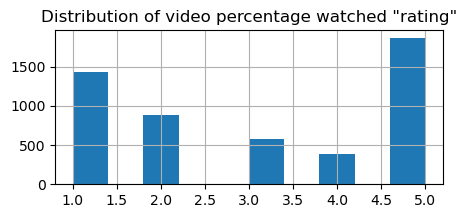

In [17]:
df_mf_tiktok_exp[["rating"]].hist(figsize=(5,2))
plt.title("Distribution of video percentage watched \"rating\"")

In [18]:
_ = calculate_density(df_mf_tiktok_exp)

Users: 80, Videos: 105
Observed interactions: 5135
Density: 0.6113
Sparsity: 0.3887


Most active user: 95 (105 ratings)
Most rated video: 0 (80 ratings)


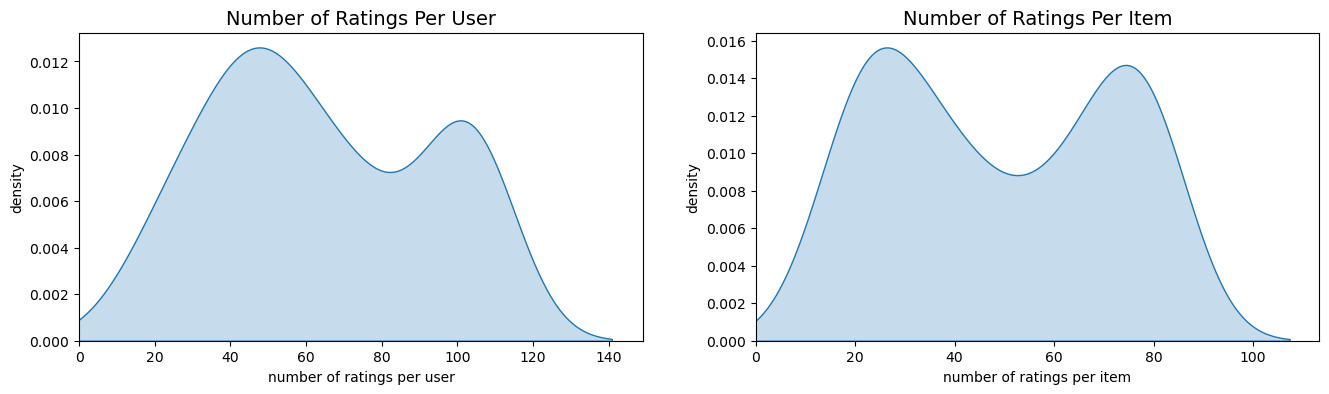

In [19]:
summary_plot_ratings(df_mf_tiktok_exp)

### Split short vs. long videos

In [20]:
def select_short_videos (df, time=100, col="video_duration"):
    video_ids_up_ts = df[df[col] <= time]["video_id"].tolist()
    video_ids_more_ts = df[df[col] > time]["video_id"].tolist()

    return video_ids_up_ts, video_ids_more_ts

In [21]:
df_tiktok_exp[["video_duration"]].describe()

,video_duration
count,5135.000000
mean,74.080039
std,99.895937
min,5.000000
25%,13.000000
50%,39.000000
75%,70.000000
max,489.000000


Text(0.5, 1.0, 'Distribution of video duration')

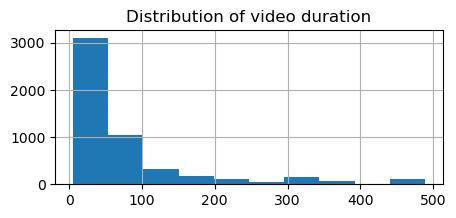

In [22]:
df_tiktok_exp[["video_duration"]].hist(figsize=(5,2))
plt.title("Distribution of video duration")

# Run MF

### TikTok Experiment data

In [23]:
_ = calculate_density(df_mf_tiktok_exp)

Users: 80, Videos: 105
Observed interactions: 5135
Density: 0.6113
Sparsity: 0.3887


In [24]:
df_mf_tiktok_exp.head()

,video_id,user_id,rating
0,0,169,5.0
1,1,169,2.0
2,2,169,1.0
3,3,169,2.0
4,4,169,4.0


In [25]:
param_grid = {
    'n_components': [2, 5, 10, 20, 50],
    'max_iter': [1000, 2000, 3000],
    'init': ['random'],
    'model_type': ['svd'],
    'n_iter': [1, 3, 5, 10, 15]
}

R_test, R_estimated, ndcg, k_ndcg, rmse, rmse_normalized, best_param = grid_search_mf_bias(df_mf_tiktok_exp, param_grid, print_info=False)

(5135, 3) (4086, 3) (1049, 3)
cold items [104]
4087 1048 1027.0

✅ Best params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 5, 'n_iter': 10}
✅ Best RMSE on TEST: 1.3325, NDCG@3: 0.8872 (len:80), normalized RMSE: 1.3325

📈 Explained Variance (for best SVD only): 0.2798844994489716

📈 Reconstruction Error (for best NMF only): None

📈 Reconstruction Error Normalized(for best NMF only): None


Test size: 1048
Accuracy: 0.3731
Precision (macro): 0.3477
Recall (macro): 0.3011
F1 Score (macro): 0.2874


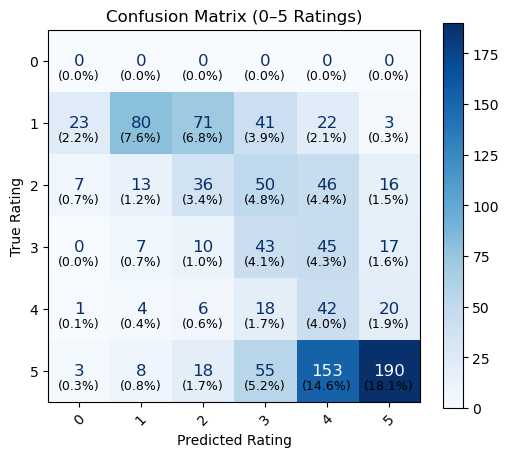

In [26]:
cm_exp, accuracy_exp, precision_exp, recall_exp, f1_exp = plot_confusion_matrix_ratings(R_test, R_estimated)

In [27]:
best_metrics = grid_search_mf_bias_loou_ndcg(df_mf_tiktok_exp, best_param)

(5135, 3)
(5135, 3)

=== Testing params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 5, 'n_iter': 10} ===
  Left-out user 48: NDCG@10=0.7969, n_test_items=38
  Left-out user 53: NDCG@10=0.8871, n_test_items=68
  Left-out user 84: NDCG@10=0.9216, n_test_items=50
  Left-out user 95: NDCG@10=0.8108, n_test_items=105
  Left-out user 115: NDCG@10=0.7625, n_test_items=105
  Left-out user 135: NDCG@10=0.8116, n_test_items=37
  Left-out user 146: NDCG@10=0.8953, n_test_items=43
  Left-out user 147: NDCG@10=0.6871, n_test_items=105
  Left-out user 155: NDCG@10=0.7691, n_test_items=39
  Left-out user 169: NDCG@10=0.7837, n_test_items=90
  Left-out user 175: NDCG@10=0.8686, n_test_items=43
  Left-out user 246: NDCG@10=0.5583, n_test_items=21
  Left-out user 270: NDCG@10=0.9686, n_test_items=70
  Left-out user 272: NDCG@10=0.5583, n_test_items=25
  Left-out user 280: NDCG@10=0.9696, n_test_items=58
  Left-out user 293: NDCG@10=0.9216, n_test_items=54
  Left-out user 2

In [28]:
best_metrics

{'avg_ndcg_loo': 0.8071340084820692,
 'k_ndcg_loo': 10,
 'rmse_loo': 1.3201712937553562,
 'rmse_normalized_loo': 0.7879323028605573,
 'num_users_loo': 80}

In [29]:
latex_code = generate_latex_table(df_mf_tiktok_exp, df_tiktok_exp)
print(latex_code)

Density all 0.6113095238095239
\begin{table}
\caption{Dataset Statistics}
\label{tab:dataset_stats}
\begin{tabular}{lrrrrrrr}
\toprule
Dataset & Size & Density & 1 & 2 & 3 & 4 & 5 \\
\midrule
All & 5135 & 0.611 & 1507 (29.3%) & 961 (18.7%) & 656 (12.8%) & 463 (9.0%) & 1948 (37.9%) \\
Short Q0.2 (12s) & 1105 & 0.628 & 118 (10.7%) & 142 (12.9%) & 165 (14.9%) & 105 (9.5%) & 655 (59.3%) \\
Long Q0.2 (12s) & 4030 & 0.607 & 1389 (34.5%) & 819 (20.3%) & 491 (12.2%) & 358 (8.9%) & 1293 (32.1%) \\
Short Q0.25 (13s) & 1365 & 0.656 & 122 (8.9%) & 179 (13.1%) & 215 (15.8%) & 140 (10.3%) & 789 (57.8%) \\
Long Q0.25 (13s) & 3770 & 0.597 & 1385 (36.7%) & 782 (20.7%) & 441 (11.7%) & 323 (8.6%) & 1159 (30.7%) \\
Short Q0.5 (39s) & 2612 & 0.695 & 286 (10.9%) & 389 (14.9%) & 365 (14.0%) & 326 (12.5%) & 1406 (53.8%) \\
Long Q0.5 (39s) & 2523 & 0.544 & 1221 (48.4%) & 572 (22.7%) & 291 (11.5%) & 137 (5.4%) & 542 (21.5%) \\
Short Q0.75 (70s) & 3888 & 0.639 & 736 (18.9%) & 648 (16.7%) & 506 (13.0%) & 416 (10.

(5135, 3) (4086, 3) (1049, 3)
cold items [104]
4087 1048 1027.0

✅ Best params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 5, 'n_iter': 10}
✅ Best RMSE on TEST: 1.3325, NDCG@3: 0.8872 (len:80), normalized RMSE: 1.3325

📈 Explained Variance (for best SVD only): 0.2798844994489716

📈 Reconstruction Error (for best NMF only): None

📈 Reconstruction Error Normalized(for best NMF only): None
All videos
Test size: 1048
Accuracy: 0.3731
Precision (macro): 0.3477
Recall (macro): 0.3011
F1 Score (macro): 0.2874


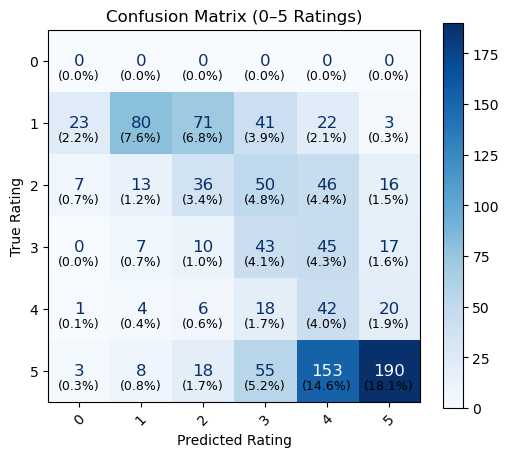

(5135, 3)
(5135, 3)

=== Testing params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 5, 'n_iter': 10} ===
  Left-out user 48: NDCG@10=0.7969, n_test_items=38
  Left-out user 53: NDCG@10=0.8871, n_test_items=68
  Left-out user 84: NDCG@10=0.9216, n_test_items=50
  Left-out user 95: NDCG@10=0.8108, n_test_items=105
  Left-out user 115: NDCG@10=0.7625, n_test_items=105
  Left-out user 135: NDCG@10=0.8116, n_test_items=37
  Left-out user 146: NDCG@10=0.8953, n_test_items=43
  Left-out user 147: NDCG@10=0.6871, n_test_items=105
  Left-out user 155: NDCG@10=0.7691, n_test_items=39
  Left-out user 169: NDCG@10=0.7837, n_test_items=90
  Left-out user 175: NDCG@10=0.8686, n_test_items=43
  Left-out user 246: NDCG@10=0.5583, n_test_items=21
  Left-out user 270: NDCG@10=0.9686, n_test_items=70
  Left-out user 272: NDCG@10=0.5583, n_test_items=25
  Left-out user 280: NDCG@10=0.9696, n_test_items=58
  Left-out user 293: NDCG@10=0.9216, n_test_items=54
  Left-out user 2

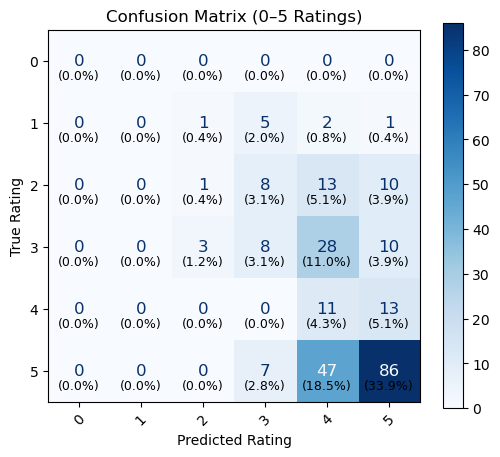

(1105, 3)
(1105, 3)

=== Testing params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 20, 'n_iter': 1} ===
  Left-out user 48: NDCG@10=0.8108, n_test_items=9
  Left-out user 53: NDCG@10=0.8137, n_test_items=14
  Left-out user 84: NDCG@10=0.8702, n_test_items=12
  Left-out user 95: NDCG@10=0.9034, n_test_items=22
  Left-out user 115: NDCG@10=0.8415, n_test_items=22
  Left-out user 135: NDCG@10=0.8536, n_test_items=9
  Left-out user 146: NDCG@10=0.8806, n_test_items=10
  Left-out user 147: NDCG@10=0.6977, n_test_items=22
  Left-out user 155: NDCG@10=0.8094, n_test_items=9
  Left-out user 169: NDCG@10=0.8397, n_test_items=18
  Left-out user 175: NDCG@10=0.8671, n_test_items=10
  Left-out user 246: NDCG@10=0.7810, n_test_items=5
  Left-out user 270: NDCG@10=0.9001, n_test_items=14
  Left-out user 272: NDCG@10=0.7879, n_test_items=6
  Left-out user 280: NDCG@10=0.9266, n_test_items=13
  Left-out user 293: NDCG@10=0.8724, n_test_items=13
  Left-out user 297: NDCG

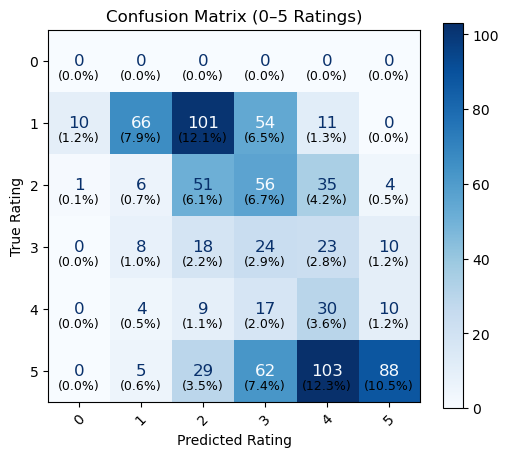

(4030, 3)
(4030, 3)

=== Testing params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 2, 'n_iter': 3} ===
  Left-out user 48: NDCG@10=0.5340, n_test_items=29
  Left-out user 53: NDCG@10=0.9073, n_test_items=54
  Left-out user 84: NDCG@10=0.7065, n_test_items=38
  Left-out user 95: NDCG@10=0.5523, n_test_items=83
  Left-out user 115: NDCG@10=0.6066, n_test_items=83
  Left-out user 135: NDCG@10=0.6927, n_test_items=28
  Left-out user 146: NDCG@10=0.6997, n_test_items=33
  Left-out user 147: NDCG@10=0.6181, n_test_items=83
  Left-out user 155: NDCG@10=0.6788, n_test_items=30
  Left-out user 169: NDCG@10=0.6659, n_test_items=72
  Left-out user 175: NDCG@10=0.6811, n_test_items=33
  Left-out user 246: NDCG@10=0.4893, n_test_items=16
  Left-out user 270: NDCG@10=0.8556, n_test_items=56
  Left-out user 272: NDCG@10=0.4893, n_test_items=19
  Left-out user 280: NDCG@10=0.7664, n_test_items=45
  Left-out user 293: NDCG@10=0.6927, n_test_items=41
  Left-out user 297: 

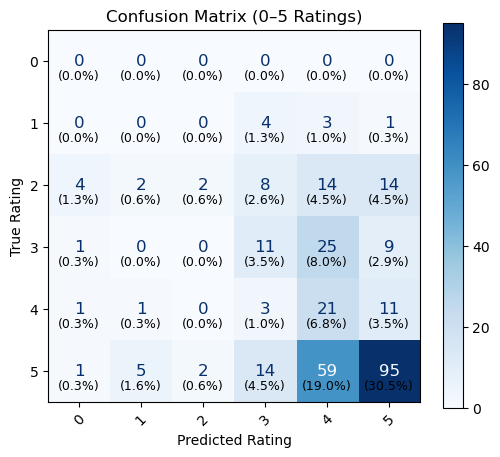

(1365, 3)
(1365, 3)

=== Testing params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 20, 'n_iter': 3} ===
  Left-out user 48: NDCG@10=0.7911, n_test_items=11
  Left-out user 53: NDCG@10=0.8010, n_test_items=18
  Left-out user 84: NDCG@10=0.8620, n_test_items=16
  Left-out user 95: NDCG@10=0.8785, n_test_items=26
  Left-out user 115: NDCG@10=0.7896, n_test_items=26
  Left-out user 135: NDCG@10=0.8379, n_test_items=11
  Left-out user 146: NDCG@10=0.8879, n_test_items=14
  Left-out user 147: NDCG@10=0.6993, n_test_items=26
  Left-out user 155: NDCG@10=0.7990, n_test_items=11
  Left-out user 169: NDCG@10=0.8026, n_test_items=22
  Left-out user 175: NDCG@10=0.8839, n_test_items=14
  Left-out user 246: NDCG@10=0.7761, n_test_items=5
  Left-out user 270: NDCG@10=0.9012, n_test_items=18
  Left-out user 272: NDCG@10=0.6924, n_test_items=6
  Left-out user 280: NDCG@10=0.9266, n_test_items=17
  Left-out user 293: NDCG@10=0.8747, n_test_items=17
  Left-out user 297: N

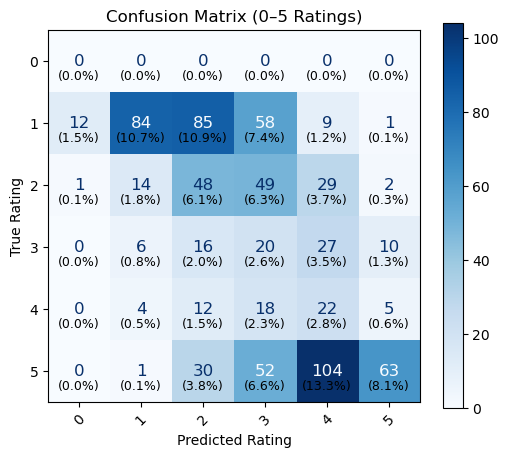

(3770, 3)
(3770, 3)

=== Testing params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 5, 'n_iter': 3} ===
  Left-out user 48: NDCG@10=0.5498, n_test_items=27
  Left-out user 53: NDCG@10=0.9049, n_test_items=50
  Left-out user 84: NDCG@10=0.6633, n_test_items=34
  Left-out user 95: NDCG@10=0.5780, n_test_items=79
  Left-out user 115: NDCG@10=0.6666, n_test_items=79
  Left-out user 135: NDCG@10=0.6487, n_test_items=26
  Left-out user 146: NDCG@10=0.6947, n_test_items=29
  Left-out user 147: NDCG@10=0.5880, n_test_items=79
  Left-out user 155: NDCG@10=0.6610, n_test_items=28
  Left-out user 169: NDCG@10=0.6563, n_test_items=68
  Left-out user 175: NDCG@10=0.6750, n_test_items=29
  Left-out user 246: NDCG@10=0.5626, n_test_items=16
  Left-out user 270: NDCG@10=0.8421, n_test_items=52
  Left-out user 272: NDCG@10=0.5626, n_test_items=19
  Left-out user 280: NDCG@10=0.7585, n_test_items=41
  Left-out user 293: NDCG@10=0.6868, n_test_items=37
  Left-out user 297: 

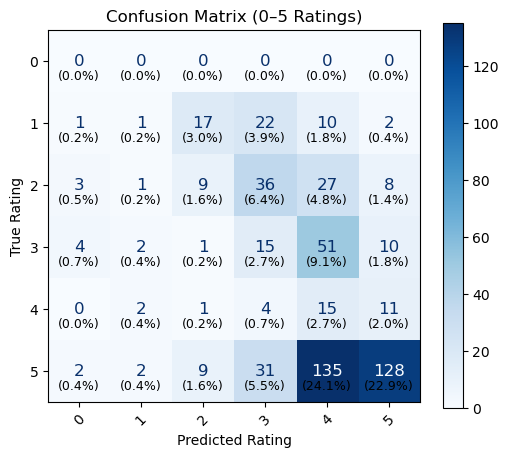

(2612, 3)
(2612, 3)

=== Testing params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 2, 'n_iter': 1} ===
  Left-out user 48: NDCG@10=0.7969, n_test_items=22
  Left-out user 53: NDCG@10=0.8871, n_test_items=36
  Left-out user 84: NDCG@10=0.9216, n_test_items=30
  Left-out user 95: NDCG@10=0.8108, n_test_items=47
  Left-out user 115: NDCG@10=0.7625, n_test_items=47
  Left-out user 135: NDCG@10=0.8116, n_test_items=22
  Left-out user 146: NDCG@10=0.8953, n_test_items=26
  Left-out user 147: NDCG@10=0.6871, n_test_items=47
  Left-out user 155: NDCG@10=0.7691, n_test_items=22
  Left-out user 169: NDCG@10=0.7837, n_test_items=42
  Left-out user 175: NDCG@10=0.8686, n_test_items=26
  Left-out user 246: NDCG@10=0.5583, n_test_items=13
  Left-out user 270: NDCG@10=0.9686, n_test_items=36
  Left-out user 272: NDCG@10=0.5583, n_test_items=14
  Left-out user 280: NDCG@10=0.9696, n_test_items=33
  Left-out user 293: NDCG@10=0.9216, n_test_items=31
  Left-out user 297: 

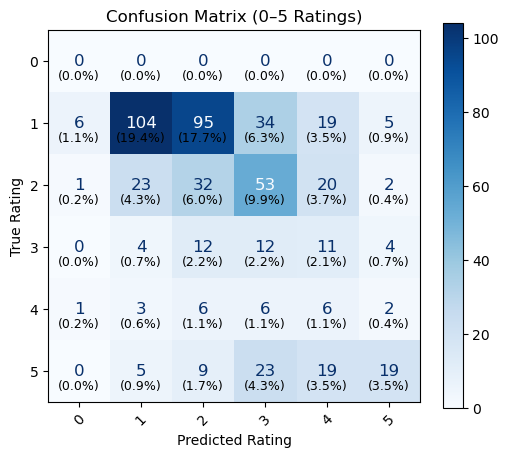

(2523, 3)
(2523, 3)

=== Testing params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 2, 'n_iter': 15} ===
  Left-out user 48: NDCG@10=0.6350, n_test_items=16
  Left-out user 53: NDCG@10=0.6150, n_test_items=32
  Left-out user 84: NDCG@10=0.8337, n_test_items=20
  Left-out user 95: NDCG@10=0.6231, n_test_items=58
  Left-out user 115: NDCG@10=0.4783, n_test_items=58
  Left-out user 135: NDCG@10=0.4614, n_test_items=15
  Left-out user 146: NDCG@10=0.7783, n_test_items=17
  Left-out user 147: NDCG@10=0.6305, n_test_items=58
  Left-out user 155: NDCG@10=0.7388, n_test_items=17
  Left-out user 169: NDCG@10=0.7806, n_test_items=48
  Left-out user 175: NDCG@10=0.7649, n_test_items=17
  Left-out user 246: NDCG@10=0.6805, n_test_items=8
  Left-out user 270: NDCG@10=0.7334, n_test_items=34
  Left-out user 272: NDCG@10=0.6128, n_test_items=11
  Left-out user 280: NDCG@10=0.7611, n_test_items=25
  Left-out user 293: NDCG@10=0.7759, n_test_items=23
  Left-out user 297: 

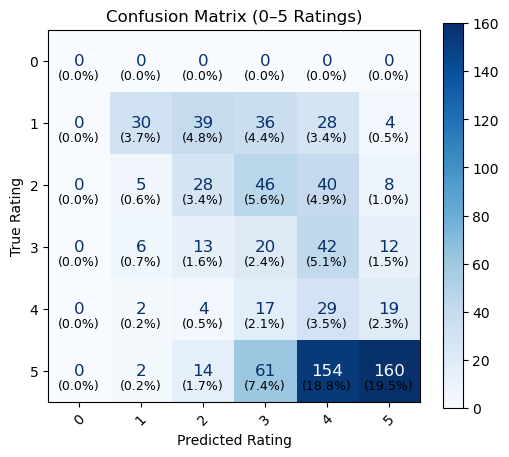

(3888, 3)
(3888, 3)

=== Testing params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 2, 'n_iter': 1} ===
  Left-out user 48: NDCG@10=0.7969, n_test_items=30
  Left-out user 53: NDCG@10=0.8871, n_test_items=54
  Left-out user 84: NDCG@10=0.9216, n_test_items=40
  Left-out user 95: NDCG@10=0.8108, n_test_items=76
  Left-out user 115: NDCG@10=0.7625, n_test_items=76
  Left-out user 135: NDCG@10=0.8116, n_test_items=29
  Left-out user 146: NDCG@10=0.8953, n_test_items=34
  Left-out user 147: NDCG@10=0.6871, n_test_items=76
  Left-out user 155: NDCG@10=0.7691, n_test_items=30
  Left-out user 169: NDCG@10=0.7837, n_test_items=67
  Left-out user 175: NDCG@10=0.8686, n_test_items=34
  Left-out user 246: NDCG@10=0.5583, n_test_items=17
  Left-out user 270: NDCG@10=0.9686, n_test_items=55
  Left-out user 272: NDCG@10=0.5583, n_test_items=19
  Left-out user 280: NDCG@10=0.9696, n_test_items=46
  Left-out user 293: NDCG@10=0.9216, n_test_items=42
  Left-out user 297: 

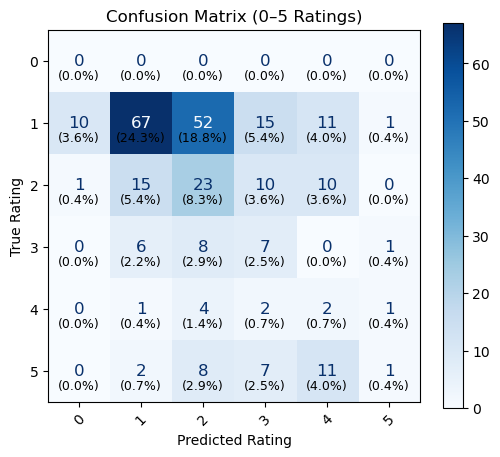

(1247, 3)
(1247, 3)

=== Testing params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 20, 'n_iter': 1} ===
  Left-out user 48: NDCG@10=0.2963, n_test_items=8
  Left-out user 53: NDCG@10=0.8752, n_test_items=14
  Left-out user 84: NDCG@10=0.6643, n_test_items=10
  Left-out user 95: NDCG@10=0.7914, n_test_items=29
  Left-out user 115: NDCG@10=0.6911, n_test_items=29
  Left-out user 135: NDCG@10=0.6302, n_test_items=8
  Left-out user 146: NDCG@10=0.6908, n_test_items=9
  Left-out user 147: NDCG@10=0.6530, n_test_items=29
  Left-out user 155: NDCG@10=0.7720, n_test_items=9
  Left-out user 169: NDCG@10=0.7737, n_test_items=23
  Left-out user 175: NDCG@10=0.7503, n_test_items=9
  Left-out user 246: NDCG@10=0.3550, n_test_items=4
  Left-out user 270: NDCG@10=0.7456, n_test_items=15
  Left-out user 272: NDCG@10=0.4475, n_test_items=6
  Left-out user 280: NDCG@10=0.7361, n_test_items=12
  Left-out user 293: NDCG@10=0.7513, n_test_items=12
  Left-out user 297: NDCG@1

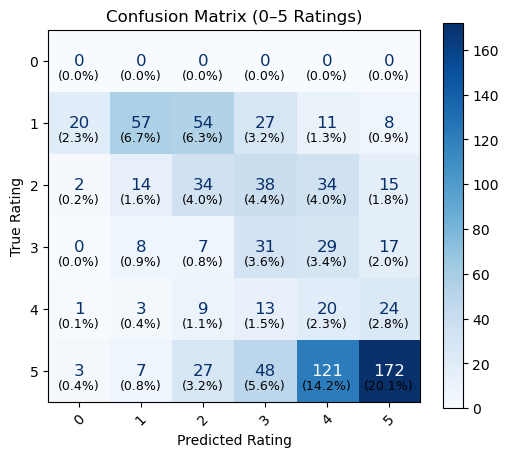

(4148, 3)
(4148, 3)

=== Testing params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 10, 'n_iter': 3} ===
  Left-out user 48: NDCG@10=0.7969, n_test_items=30
  Left-out user 53: NDCG@10=0.8871, n_test_items=56
  Left-out user 84: NDCG@10=0.9216, n_test_items=41
  Left-out user 95: NDCG@10=0.8108, n_test_items=85
  Left-out user 115: NDCG@10=0.7625, n_test_items=85
  Left-out user 135: NDCG@10=0.8116, n_test_items=29
  Left-out user 146: NDCG@10=0.8953, n_test_items=35
  Left-out user 147: NDCG@10=0.6871, n_test_items=85
  Left-out user 155: NDCG@10=0.7691, n_test_items=31
  Left-out user 169: NDCG@10=0.7837, n_test_items=71
  Left-out user 175: NDCG@10=0.8686, n_test_items=35
  Left-out user 246: NDCG@10=0.5583, n_test_items=17
  Left-out user 270: NDCG@10=0.9686, n_test_items=58
  Left-out user 272: NDCG@10=0.5583, n_test_items=19
  Left-out user 280: NDCG@10=0.9696, n_test_items=48
  Left-out user 293: NDCG@10=0.9216, n_test_items=44
  Left-out user 297:

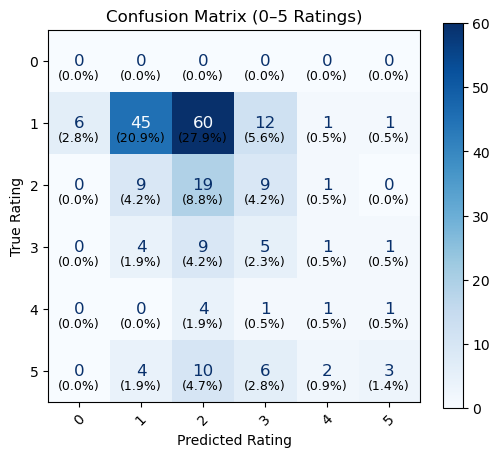

(987, 3)
(987, 3)

=== Testing params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 2, 'n_iter': 5} ===
  Left-out user 48: NDCG@10=0.4318, n_test_items=8
  Left-out user 53: NDCG@10=0.7502, n_test_items=12
  Left-out user 84: NDCG@10=0.7773, n_test_items=9
  Left-out user 95: NDCG@10=0.8230, n_test_items=20
  Left-out user 115: NDCG@10=0.8196, n_test_items=20
  Left-out user 135: NDCG@10=0.8612, n_test_items=8
  Left-out user 146: NDCG@10=0.5181, n_test_items=8
  Left-out user 147: NDCG@10=0.7706, n_test_items=20
  Left-out user 155: NDCG@10=0.6662, n_test_items=8
  Left-out user 169: NDCG@10=0.6918, n_test_items=19
  Left-out user 175: NDCG@10=0.5596, n_test_items=8
  Left-out user 246: NDCG@10=0.4564, n_test_items=4
  Left-out user 270: NDCG@10=0.6442, n_test_items=12
  Left-out user 272: NDCG@10=0.5300, n_test_items=6
  Left-out user 280: NDCG@10=0.5985, n_test_items=10
  Left-out user 293: NDCG@10=0.6563, n_test_items=10
  Left-out user 297: NDCG@10=0.

In [30]:
#✅ Best params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 5, 'n_iter': 10}
#✅ Best RMSE on TEST: 1.3325, NDCG@3: 0.8872, normalized RMSE: 1.3325
param_grid = {
    'n_components': [2, 5, 10, 20],
    'max_iter': [1000, 2000, 3000],
    'init': ['random'],
    'model_type': ['svd'],
    'n_iter': [1, 3, 5, 10, 15]
}


results_exp = []
results_combine = []

R_test, R_estimated, ndcg, k_ndcg, rmse, rmse_normalized, best_param = grid_search_mf_bias(df_mf_tiktok_exp, param_grid, print_info=False)
print("All videos")
cm, acc, pre, rec, f1s = plot_confusion_matrix_ratings(R_test, R_estimated)
best_metrics = grid_search_mf_bias_loou_ndcg(df_mf_tiktok_exp, best_param)

d = {"Data": "TikTok Experiment",
    "Quantile": 1.0, 
    "Duration": np.nan, 
    "Type": "all", 
    "Accuracy": accuracy_exp, 
    "Precision": precision_exp, 
    "Recall": recall_exp, 
    "F1 score": f1_exp,
    "ndcg": ndcg,
    "k_ndcg": k_ndcg,
    "rmse": rmse,
    "rmse_norm": rmse_normalized
}
d.update(best_metrics)
results_exp.append(d)

d = {"Data": "TikTok Experiment", 
    "Accuracy": acc, 
    "Precision": pre, 
    "Recall": rec, 
    "F1 score": f1s,
    "ndcg": ndcg,
    "k_ndcg": k_ndcg,
    "rmse": rmse,
    "rmse_norm": rmse_normalized,
    "density": calculate_density(df_mf_tiktok_exp)
}
d.update(best_metrics)
results_combine.append(d)


for q in [0.2, 0.25, 0.5, 0.75, 0.8]:
    t = int(df_tiktok_exp[["video_duration"]].quantile(q).iloc[0])
    print(f"Time split: {t}")
    video_ids_up_ts, video_ids_more_ts = select_short_videos(df_tiktok_exp, time=t, col="video_duration")

    data_up_ts = df_mf_tiktok_exp[df_mf_tiktok_exp["video_id"].isin(video_ids_up_ts)]
    R_test, R_estimated, ndcg, k_ndcg, rmse, rmse_normalized, best_param = grid_search_mf_bias(data_up_ts, param_grid, print_info=False)
    print("Short videos")
    cm, acc, pre, rec, f1s = plot_confusion_matrix_ratings(R_test, R_estimated)
    best_metrics = grid_search_mf_bias_loou_ndcg(data_up_ts, best_param)

    d = {"Data": "TikTok Experiment", "Quantile": q, "Duration": t, "Type": "short", 
    "Accuracy": acc, 
    "Precision": pre, 
    "Recall": rec, 
    "F1 score": f1s,
    "ndcg": ndcg,
    "k_ndcg": k_ndcg,
    "rmse": rmse,
    "rmse_norm": rmse_normalized
    }
    d.update(best_metrics)
    results_exp.append(d)
    
    
    data_more_ts = df_mf_tiktok_exp[df_mf_tiktok_exp["video_id"].isin(video_ids_more_ts)]
    R_test, R_estimated, ndcg, k_ndcg, rmse, rmse_normalized, best_param = grid_search_mf_bias(data_more_ts, param_grid, print_info=False)
    print("Long videos")
    cm, acc, pre, rec, f1s = plot_confusion_matrix_ratings(R_test, R_estimated)
    best_metrics = grid_search_mf_bias_loou_ndcg(data_more_ts, best_param)
    d = {"Data": "TikTok Experiment", "Quantile": q, "Duration": t, "Type": "long", 
    "Accuracy": acc, 
    "Precision": pre, 
    "Recall": rec, 
    "F1 score": f1s,
    "ndcg": ndcg,
    "k_ndcg": k_ndcg,
    "rmse": rmse,
    "rmse_norm": rmse_normalized
    }
    d.update(best_metrics)
    results_exp.append(d)
    

In [31]:
df_results_exp = pd.DataFrame(results_exp)
df_results_exp

,Data,Quantile,Duration,Type,Accuracy,Precision,Recall,F1 score,ndcg,k_ndcg,rmse,rmse_norm,avg_ndcg_loo,k_ndcg_loo,rmse_loo,rmse_normalized_loo,num_users_loo
0,TikTok Experiment,1.00,NaN,all,0.373092,0.347676,0.301097,0.287353,0.887181,3,1.332465,0.809023,0.807134,10,1.320171,0.787932,80
1,TikTok Experiment,0.20,12.0,short,0.417323,0.262258,0.253427,0.219877,0.908932,3,1.186027,0.947479,0.844692,10,1.179473,0.944734,80
2,TikTok Experiment,0.20,12.0,long,0.310180,0.338945,0.271735,0.250866,0.864730,3,1.343601,0.802794,0.694605,10,1.356202,0.811314,80
3,TikTok Experiment,0.25,13.0,short,0.414791,0.279650,0.231988,0.204036,0.907812,3,1.414547,1.151942,0.817625,10,1.181765,0.954575,80
4,TikTok Experiment,0.25,13.0,long,0.303069,0.336072,0.256472,0.242816,0.847054,3,1.342449,0.801861,0.701374,10,1.366832,0.819141,80
5,TikTok Experiment,0.50,39.0,short,0.300000,0.229198,0.196370,0.166445,0.882140,3,1.355876,0.932455,0.808681,10,1.296641,0.924978,80
6,TikTok Experiment,0.50,39.0,long,0.322761,0.287249,0.237019,0.226446,0.815626,3,1.388349,0.981821,0.693158,10,1.344098,0.873741,80
7,TikTok Experiment,0.75,70.0,short,0.326007,0.390129,0.294432,0.284628,0.874528,3,1.345527,0.848288,0.807518,10,1.351342,0.856154,80
8,TikTok Experiment,0.75,70.0,long,0.362319,0.242987,0.228664,0.202491,0.834114,3,1.330008,1.012375,0.638541,10,1.217874,0.933836,80
9,TikTok Experiment,0.80,96.0,short,0.367681,0.319880,0.274651,0.271985,0.846547,3,1.417454,0.864551,0.807412,10,1.343642,0.835288,80


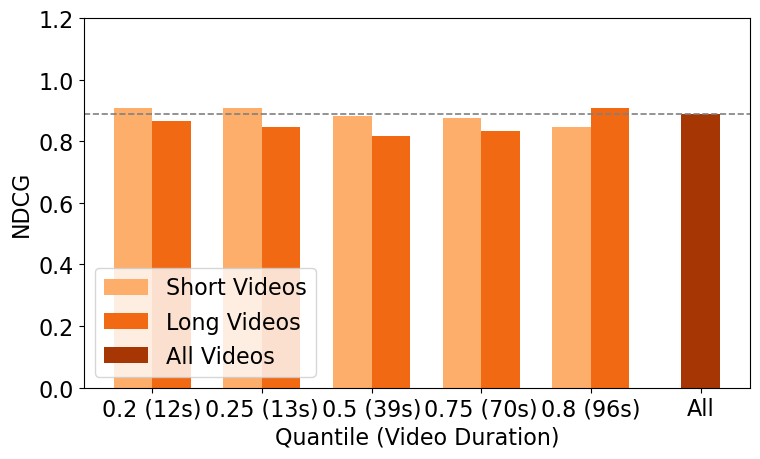

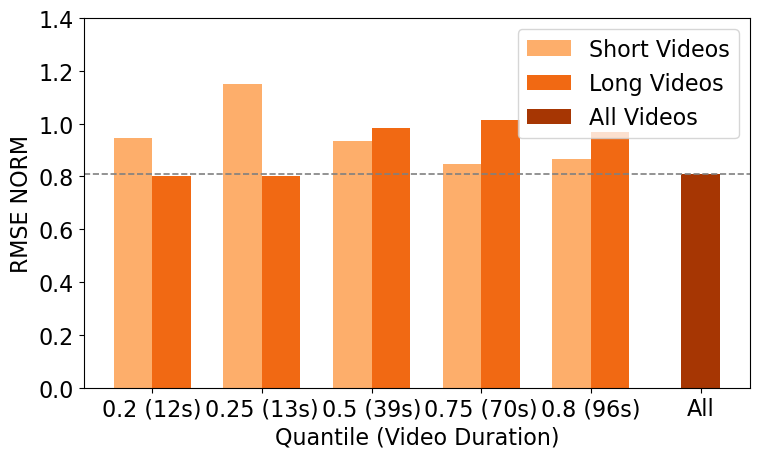

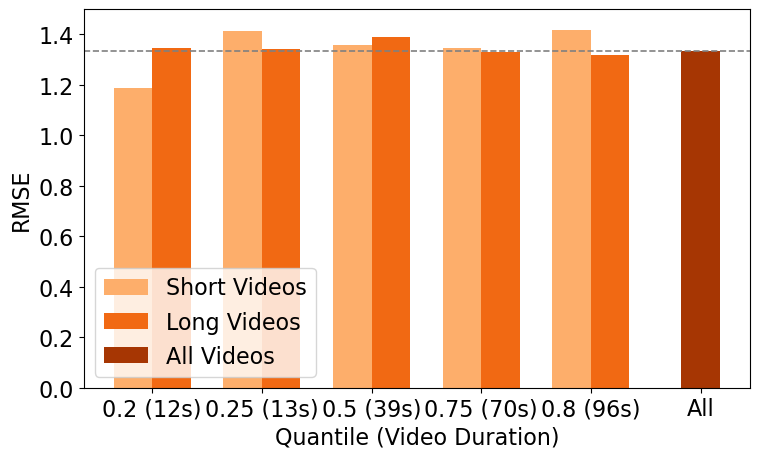

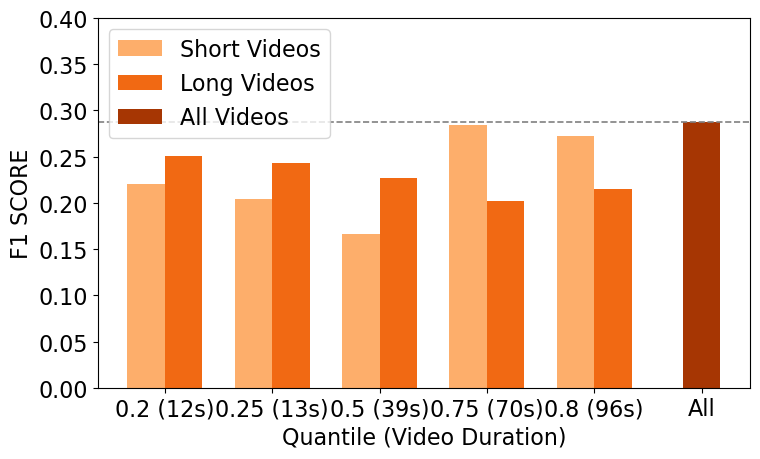

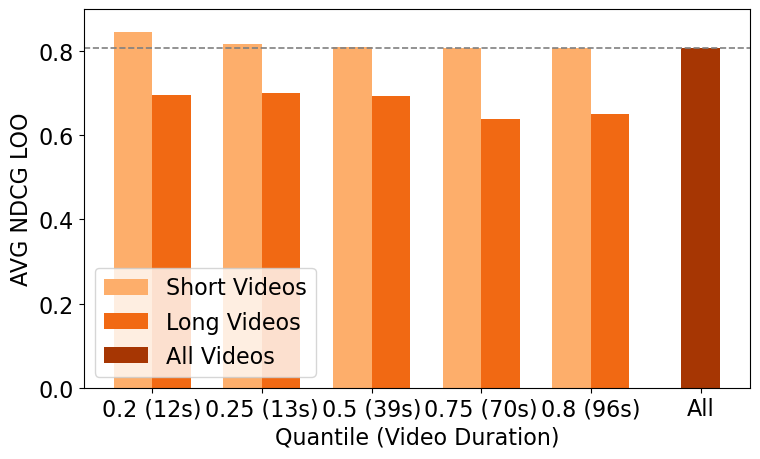

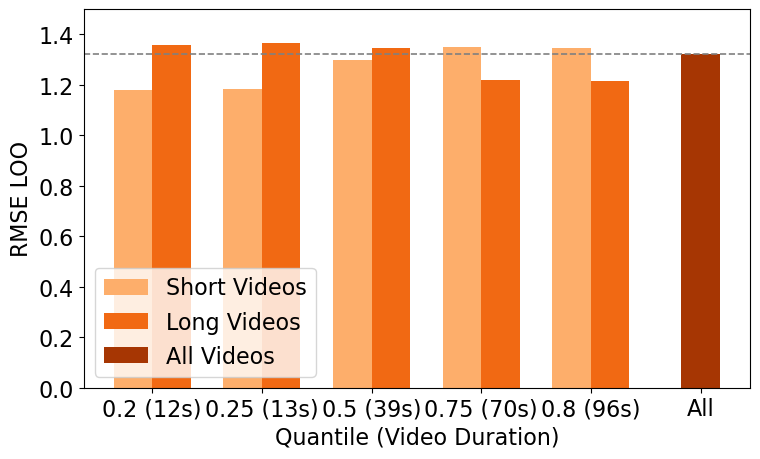

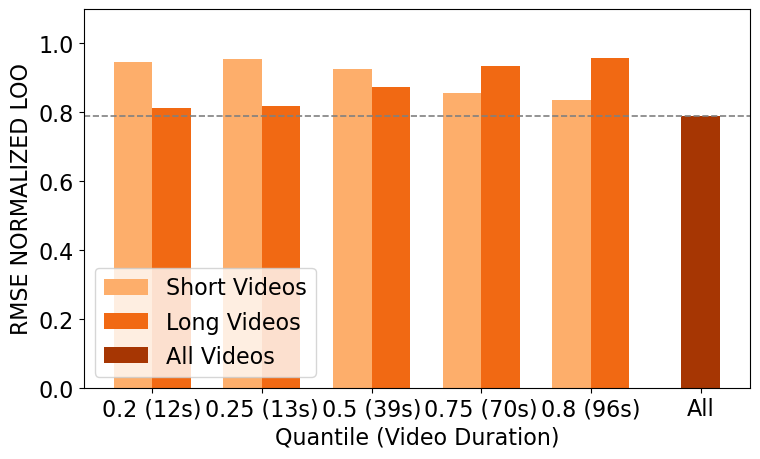

In [32]:
set_dim_fig(sizes=(16,20,20))
plot_mf_summary(df_results_exp, note="tiktok-exp")
set_dim_fig()

In [33]:
df_results_exp.to_csv("data/results_mf_exp.csv")

# Matrix Factorization TikTok Real World data and ML

## TikTok Real World data

In [34]:
df_tiktok_real = pd.read_csv("data/mf_perc_all_donations_real_world.csv", index_col=0)
df_tiktok_real.rename(columns={"email_md5": "user_id"}, inplace=True)
df_tiktok_real.head(5)

,user_id,video_id,video_duration,percentage_watched
0,4b11a2f56b0d686648a07460df5c0b76,6904810145583287557,13.0,154.0
1,4b11a2f56b0d686648a07460df5c0b76,6924107678360931590,32.0,38.0
2,4b11a2f56b0d686648a07460df5c0b76,6927315557029104902,21.0,114.0
3,4b11a2f56b0d686648a07460df5c0b76,6936164872799538438,15.0,33.0
4,4b11a2f56b0d686648a07460df5c0b76,6933686129736682757,33.0,42.0


In [35]:
_ = calculate_density(df_tiktok_real)

Users: 347, Videos: 4121911
Observed interactions: 7941712
Density: 0.0056
Sparsity: 0.9944


#### Reduzing the sparcity of TikTok Real World data

In [36]:
def create_subsample_videos_users(df, col_user='user_id', col_video='video_id', num=15):
    while True:
        # Filter videos
        video_user_counts = df.groupby(col_video)[col_user].nunique()
        valid_videos = video_user_counts[video_user_counts >= num].index
        df = df[df[col_video].isin(valid_videos)]
        
        # Filter users
        user_video_counts = df.groupby(col_user)[col_video].nunique()
        valid_users = user_video_counts[user_video_counts >= num].index
        df = df[df[col_user].isin(valid_users)]
        
        # Check if all constraints are satisfied
        if df.groupby(col_user)[col_video].nunique().min() >= num and \
           df.groupby(col_video)[col_user].nunique().min() >= num:
            break

    print(f"Remaining users: {df[col_user].nunique()}")
    print(f"Remaining videos: {df[col_video].nunique()}")
    print(f"Remaining interactions: {len(df)}")
    
    return df
    

In [37]:
df_tiktok_real = create_subsample_videos_users(df_tiktok_real, num=15) 
# only videos watched by AT LEAST *NUM* people & people who watched AT LEAST *NUM* videos

Remaining users: 334
Remaining videos: 21416
Remaining interactions: 598251


In [38]:
df_mf_tiktok_real = df_tiktok_real.loc[:,["video_id", "user_id", "percentage_watched"]]

### Rating 1-5

In [39]:
df_mf_tiktok_real = df_mf_tiktok_real.rename(columns={"percentage_watched": "rating"})
df_mf_tiktok_real["rating"] = df_mf_tiktok_real["rating"].clip(0, 100)
df_mf_tiktok_real["rating"] = round((df_mf_tiktok_real["rating"]/100) * 4 + 1, 0) #rating 1-5

Text(0.5, 1.0, 'Distribution of video percentage watched "rating"')

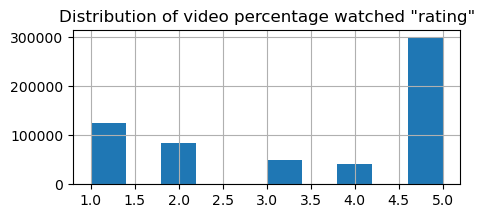

In [40]:
df_mf_tiktok_real[["rating"]].hist(figsize=(5,2))
plt.title("Distribution of video percentage watched \"rating\"")

In [41]:
_ = calculate_density(df_mf_tiktok_real)

Users: 334, Videos: 21416
Observed interactions: 598251
Density: 0.0836
Sparsity: 0.9164


Most active user: db528c1228870a562aabb4e85f81636d (8531 ratings)
Most rated video: 6979490739889753350 (157 ratings)


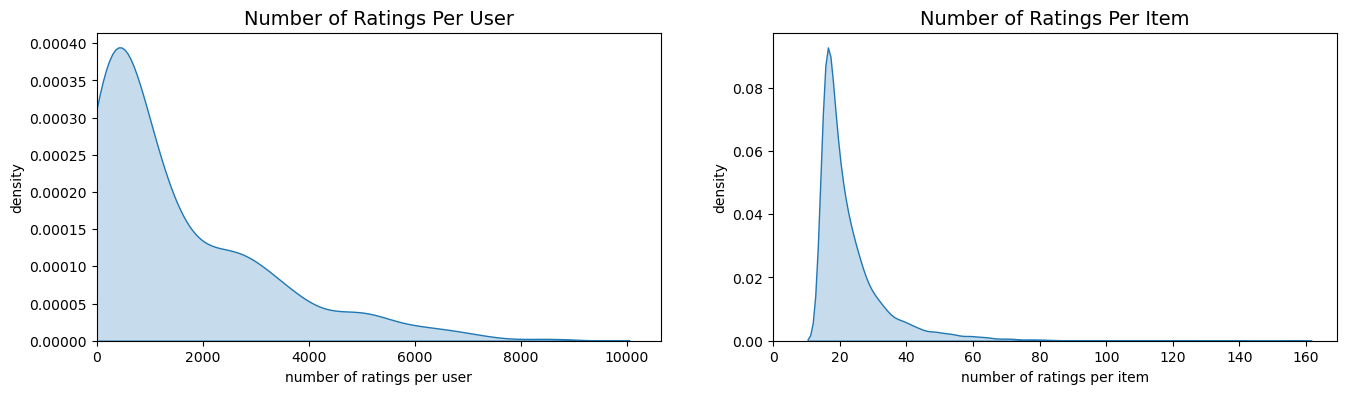

In [42]:
summary_plot_ratings(df_mf_tiktok_real)

In [43]:
df_tiktok_real[["video_duration"]].describe()

,video_duration
count,598251.000000
mean,28.861688
std,30.549176
min,0.000000
25%,12.000000
50%,17.000000
75%,33.000000
max,300.000000


Text(0.5, 1.0, 'Distribution of video duration')

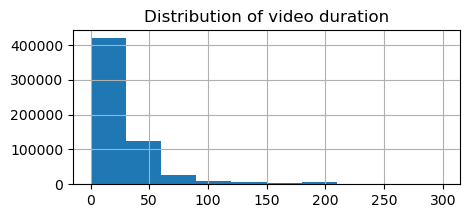

In [44]:
df_tiktok_real[["video_duration"]].hist(figsize=(5,2))
plt.title("Distribution of video duration")

In [45]:
param_grid = {
    'n_components': [2, 5, 10, 20, 50, 100, 124],
    'max_iter': [1000, 2000, 3000],
    'init': ['random'],
    'model_type': ['svd'],
    'n_iter': [1, 3, 5, 10, 15]
}

R_test, R_estimated, ndcg, k_ndcg, rmse, rmse_normalized, best_param = grid_search_mf_bias(df_mf_tiktok_real, param_grid, print_info=False)

(598251, 3) (478471, 3) (119780, 3)
478471 119780 119650.20000000001

✅ Best params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 2, 'n_iter': 1}
✅ Best RMSE on TEST: 1.5466, NDCG@3: 0.8031 (len:334), normalized RMSE: 1.5466

📈 Explained Variance (for best SVD only): 0.027520242669569688

📈 Reconstruction Error (for best NMF only): None

📈 Reconstruction Error Normalized(for best NMF only): None


Test size: 114212
Accuracy: 0.1854
Precision (macro): 0.3054
Recall (macro): 0.2113
F1 Score (macro): 0.1447


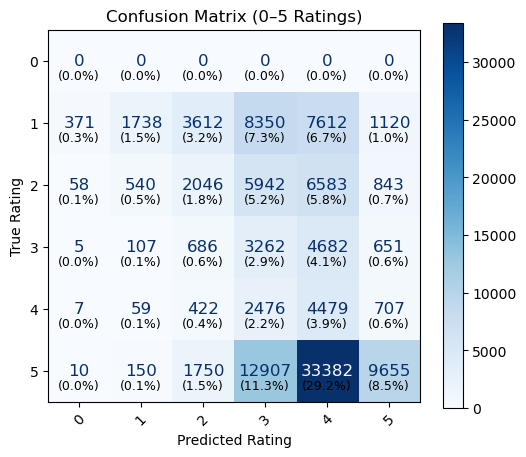

In [46]:
cm = plot_confusion_matrix_ratings(R_test, R_estimated)

In [47]:
best_metrics = grid_search_mf_bias_loou_ndcg(df_mf_tiktok_real, best_param)

(598251, 3)
(598251, 3)

=== Testing params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 2, 'n_iter': 1} ===
  Left-out user 052f9630e3db689123da58fc108031d9: NDCG@10=0.0000, n_test_items=323
  Left-out user 05ab0303fcacd5a317b2ae09139d2f90: NDCG@10=0.2091, n_test_items=3647
  Left-out user 05e5cb7c62f3231151833fc2f9c14e26: NDCG@10=0.0000, n_test_items=251
  Left-out user 076f72958232d0807c41c7e9f998f700: NDCG@10=0.0000, n_test_items=3043
  Left-out user 087b10f90b88c964f3753b2e96d692af: NDCG@10=0.0000, n_test_items=35
  Left-out user 0b21e0687828ef44ea07681a70516403: NDCG@10=0.2381, n_test_items=2400
  Left-out user 0d3e5f43ebd0e0e1e7b6cd0dea2c834a: NDCG@10=0.0000, n_test_items=57
  Left-out user 0d9cb0e2fc8cdcc2c14f9280e68d7675: NDCG@10=0.0000, n_test_items=198
  Left-out user 0dbe1e9bc9b5fa04df02d7d41387200f: NDCG@10=0.0000, n_test_items=56
  Left-out user 0e69a81894779495dc08cecca018fb58: NDCG@10=0.0000, n_test_items=888
  Left-out user 0e95162c2b3c148

In [48]:
best_metrics

{'avg_ndcg_loo': 0.05509899424439909,
 'k_ndcg_loo': 10,
 'rmse_loo': 1.5483815838399166,
 'rmse_normalized_loo': 0.9504533296381085,
 'num_users_loo': 334}

In [49]:
latex_code = generate_latex_table(df_mf_tiktok_real, df_tiktok_real)
print(latex_code)

Density all 0.08363703113011929
\begin{table}
\caption{Dataset Statistics}
\label{tab:dataset_stats}
\begin{tabular}{lrrrrrrr}
\toprule
Dataset & Size & Density & 1 & 2 & 3 & 4 & 5 \\
\midrule
All & 598251 & 0.084 & 123911 (20.7%) & 84947 (14.2%) & 48754 (8.1%) & 41889 (7.0%) & 298750 (49.9%) \\
Short Q0.2 (11s) & 133444 & 0.078 & 14794 (11.1%) & 15433 (11.6%) & 10171 (7.6%) & 7958 (6.0%) & 85088 (63.8%) \\
Long Q0.2 (11s) & 464807 & 0.085 & 109117 (23.5%) & 69514 (15.0%) & 38583 (8.3%) & 33931 (7.3%) & 213662 (46.0%) \\
Short Q0.25 (12s) & 155449 & 0.079 & 17809 (11.5%) & 18595 (12.0%) & 11862 (7.6%) & 9522 (6.1%) & 97661 (62.8%) \\
Long Q0.25 (12s) & 442802 & 0.086 & 106102 (24.0%) & 66352 (15.0%) & 36892 (8.3%) & 32367 (7.3%) & 201089 (45.4%) \\
Short Q0.5 (17s) & 307619 & 0.082 & 40728 (13.2%) & 43412 (14.1%) & 25441 (8.3%) & 22447 (7.3%) & 175591 (57.1%) \\
Long Q0.5 (17s) & 290632 & 0.085 & 83183 (28.6%) & 41535 (14.3%) & 23313 (8.0%) & 19442 (6.7%) & 123159 (42.4%) \\
Short Q0.7

(598251, 3) (478471, 3) (119780, 3)
478471 119780 119650.20000000001

✅ Best params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 2, 'n_iter': 1}
✅ Best RMSE on TEST: 1.5466, NDCG@3: 0.8031 (len:334), normalized RMSE: 1.5466

📈 Explained Variance (for best SVD only): 0.027520242669569688

📈 Reconstruction Error (for best NMF only): None

📈 Reconstruction Error Normalized(for best NMF only): None
All videos
Test size: 114212
Accuracy: 0.1854
Precision (macro): 0.3054
Recall (macro): 0.2113
F1 Score (macro): 0.1447


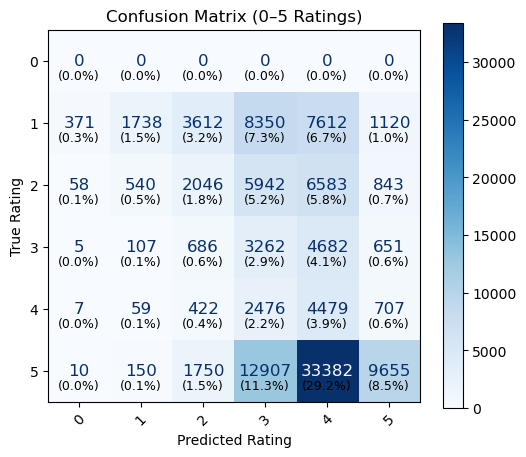

(598251, 3)
(598251, 3)

=== Testing params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 2, 'n_iter': 1} ===
  Left-out user 052f9630e3db689123da58fc108031d9: NDCG@10=0.0000, n_test_items=323
  Left-out user 05ab0303fcacd5a317b2ae09139d2f90: NDCG@10=0.2091, n_test_items=3647
  Left-out user 05e5cb7c62f3231151833fc2f9c14e26: NDCG@10=0.0000, n_test_items=251
  Left-out user 076f72958232d0807c41c7e9f998f700: NDCG@10=0.0000, n_test_items=3043
  Left-out user 087b10f90b88c964f3753b2e96d692af: NDCG@10=0.0000, n_test_items=35
  Left-out user 0b21e0687828ef44ea07681a70516403: NDCG@10=0.2381, n_test_items=2400
  Left-out user 0d3e5f43ebd0e0e1e7b6cd0dea2c834a: NDCG@10=0.0000, n_test_items=57
  Left-out user 0d9cb0e2fc8cdcc2c14f9280e68d7675: NDCG@10=0.0000, n_test_items=198
  Left-out user 0dbe1e9bc9b5fa04df02d7d41387200f: NDCG@10=0.0000, n_test_items=56
  Left-out user 0e69a81894779495dc08cecca018fb58: NDCG@10=0.0000, n_test_items=888
  Left-out user 0e95162c2b3c148

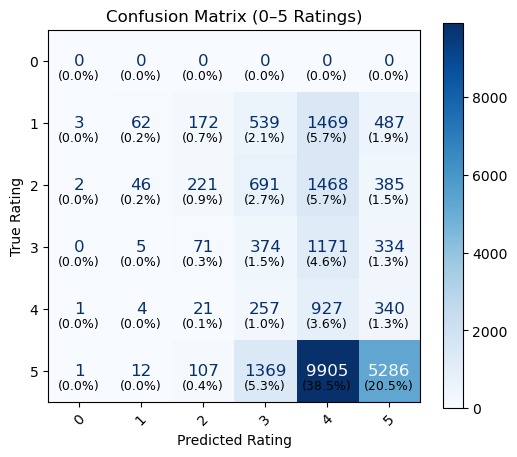

(133444, 3)
(133443, 3)

=== Testing params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 2, 'n_iter': 1} ===
  Left-out user 052f9630e3db689123da58fc108031d9: NDCG@10=0.0000, n_test_items=51
  Left-out user 05ab0303fcacd5a317b2ae09139d2f90: NDCG@10=0.1625, n_test_items=622
  Left-out user 05e5cb7c62f3231151833fc2f9c14e26: NDCG@10=0.0000, n_test_items=25
  Left-out user 076f72958232d0807c41c7e9f998f700: NDCG@10=0.0000, n_test_items=620
  Left-out user 087b10f90b88c964f3753b2e96d692af: NDCG@10=0.0000, n_test_items=8
  Left-out user 0b21e0687828ef44ea07681a70516403: NDCG@10=0.2667, n_test_items=532
  Left-out user 0d3e5f43ebd0e0e1e7b6cd0dea2c834a: NDCG@10=0.0000, n_test_items=7
  Left-out user 0d9cb0e2fc8cdcc2c14f9280e68d7675: NDCG@10=0.0000, n_test_items=72
  Left-out user 0dbe1e9bc9b5fa04df02d7d41387200f: NDCG@10=0.0000, n_test_items=8
  Left-out user 0e69a81894779495dc08cecca018fb58: NDCG@10=0.0000, n_test_items=146
  Left-out user 0e95162c2b3c14828987a496

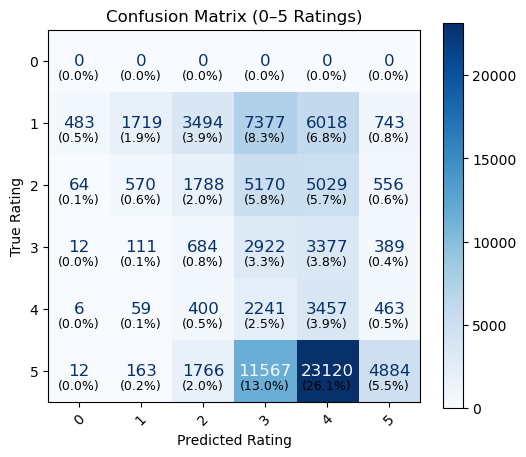

(464807, 3)
(464807, 3)

=== Testing params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 2, 'n_iter': 1} ===
  Left-out user 052f9630e3db689123da58fc108031d9: NDCG@10=0.0000, n_test_items=272
  Left-out user 05ab0303fcacd5a317b2ae09139d2f90: NDCG@10=0.2424, n_test_items=3025
  Left-out user 05e5cb7c62f3231151833fc2f9c14e26: NDCG@10=0.0000, n_test_items=226
  Left-out user 076f72958232d0807c41c7e9f998f700: NDCG@10=0.0147, n_test_items=2423
  Left-out user 087b10f90b88c964f3753b2e96d692af: NDCG@10=0.0000, n_test_items=27
  Left-out user 0b21e0687828ef44ea07681a70516403: NDCG@10=0.1877, n_test_items=1868
  Left-out user 0d3e5f43ebd0e0e1e7b6cd0dea2c834a: NDCG@10=0.0000, n_test_items=50
  Left-out user 0d9cb0e2fc8cdcc2c14f9280e68d7675: NDCG@10=0.0000, n_test_items=126
  Left-out user 0dbe1e9bc9b5fa04df02d7d41387200f: NDCG@10=0.0000, n_test_items=48
  Left-out user 0e69a81894779495dc08cecca018fb58: NDCG@10=0.0000, n_test_items=742
  Left-out user 0e95162c2b3c148

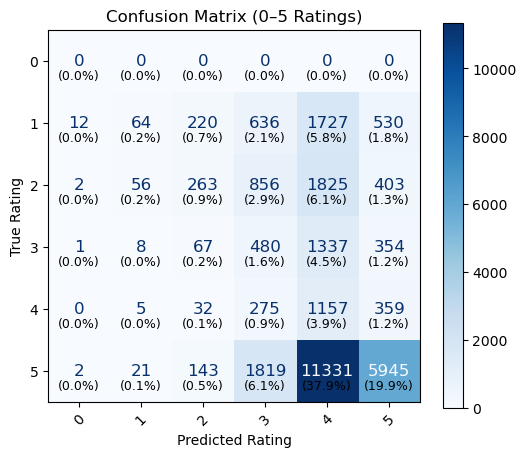

(155449, 3)
(155448, 3)

=== Testing params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 2, 'n_iter': 1} ===
  Left-out user 052f9630e3db689123da58fc108031d9: NDCG@10=0.0000, n_test_items=61
  Left-out user 05ab0303fcacd5a317b2ae09139d2f90: NDCG@10=0.1625, n_test_items=768
  Left-out user 05e5cb7c62f3231151833fc2f9c14e26: NDCG@10=0.0000, n_test_items=31
  Left-out user 076f72958232d0807c41c7e9f998f700: NDCG@10=0.0000, n_test_items=746
  Left-out user 087b10f90b88c964f3753b2e96d692af: NDCG@10=0.0000, n_test_items=9
  Left-out user 0b21e0687828ef44ea07681a70516403: NDCG@10=0.2667, n_test_items=622
  Left-out user 0d3e5f43ebd0e0e1e7b6cd0dea2c834a: NDCG@10=0.0000, n_test_items=11
  Left-out user 0d9cb0e2fc8cdcc2c14f9280e68d7675: NDCG@10=0.0000, n_test_items=89
  Left-out user 0dbe1e9bc9b5fa04df02d7d41387200f: NDCG@10=0.0000, n_test_items=11
  Left-out user 0e69a81894779495dc08cecca018fb58: NDCG@10=0.0000, n_test_items=172
  Left-out user 0e95162c2b3c14828987a4

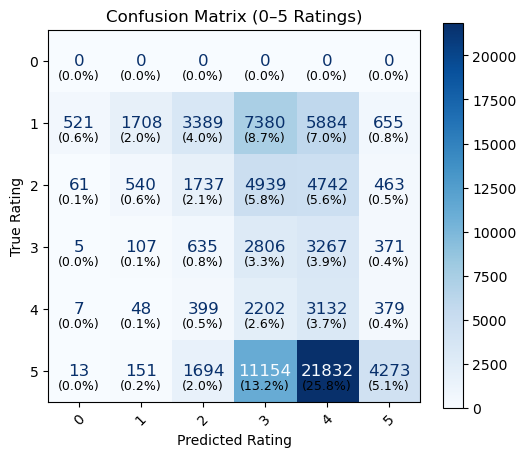

(442802, 3)
(442802, 3)

=== Testing params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 2, 'n_iter': 1} ===
  Left-out user 052f9630e3db689123da58fc108031d9: NDCG@10=0.0000, n_test_items=262
  Left-out user 05ab0303fcacd5a317b2ae09139d2f90: NDCG@10=0.3061, n_test_items=2879
  Left-out user 05e5cb7c62f3231151833fc2f9c14e26: NDCG@10=0.0000, n_test_items=220
  Left-out user 076f72958232d0807c41c7e9f998f700: NDCG@10=0.0147, n_test_items=2297
  Left-out user 087b10f90b88c964f3753b2e96d692af: NDCG@10=0.0000, n_test_items=26
  Left-out user 0b21e0687828ef44ea07681a70516403: NDCG@10=0.2527, n_test_items=1778
  Left-out user 0d3e5f43ebd0e0e1e7b6cd0dea2c834a: NDCG@10=0.0000, n_test_items=46
  Left-out user 0d9cb0e2fc8cdcc2c14f9280e68d7675: NDCG@10=0.0000, n_test_items=109
  Left-out user 0dbe1e9bc9b5fa04df02d7d41387200f: NDCG@10=0.0000, n_test_items=45
  Left-out user 0e69a81894779495dc08cecca018fb58: NDCG@10=0.0000, n_test_items=716
  Left-out user 0e95162c2b3c148

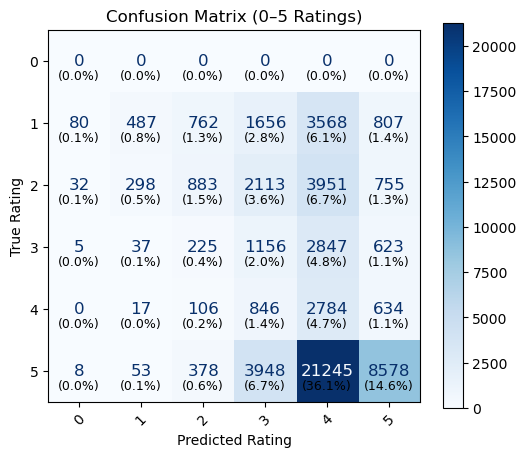

(307619, 3)
(307619, 3)

=== Testing params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 2, 'n_iter': 1} ===
  Left-out user 052f9630e3db689123da58fc108031d9: NDCG@10=0.0000, n_test_items=153
  Left-out user 05ab0303fcacd5a317b2ae09139d2f90: NDCG@10=0.1529, n_test_items=1535
  Left-out user 05e5cb7c62f3231151833fc2f9c14e26: NDCG@10=0.0000, n_test_items=110
  Left-out user 076f72958232d0807c41c7e9f998f700: NDCG@10=0.0000, n_test_items=1580
  Left-out user 087b10f90b88c964f3753b2e96d692af: NDCG@10=0.0000, n_test_items=27
  Left-out user 0b21e0687828ef44ea07681a70516403: NDCG@10=0.2500, n_test_items=1155
  Left-out user 0d3e5f43ebd0e0e1e7b6cd0dea2c834a: NDCG@10=0.0000, n_test_items=24
  Left-out user 0d9cb0e2fc8cdcc2c14f9280e68d7675: NDCG@10=0.0000, n_test_items=142
  Left-out user 0dbe1e9bc9b5fa04df02d7d41387200f: NDCG@10=0.0000, n_test_items=26
  Left-out user 0e69a81894779495dc08cecca018fb58: NDCG@10=0.0000, n_test_items=475
  Left-out user 0e95162c2b3c148

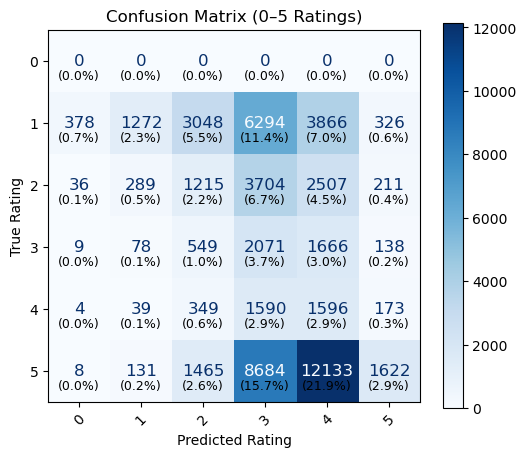

(290632, 3)
(290632, 3)

=== Testing params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 2, 'n_iter': 1} ===
  Left-out user 052f9630e3db689123da58fc108031d9: NDCG@10=0.0000, n_test_items=170
  Left-out user 05ab0303fcacd5a317b2ae09139d2f90: NDCG@10=0.2875, n_test_items=2112
  Left-out user 05e5cb7c62f3231151833fc2f9c14e26: NDCG@10=0.0000, n_test_items=141
  Left-out user 076f72958232d0807c41c7e9f998f700: NDCG@10=0.0793, n_test_items=1463
  Left-out user 087b10f90b88c964f3753b2e96d692af: NDCG@10=0.0000, n_test_items=8
  Left-out user 0b21e0687828ef44ea07681a70516403: NDCG@10=0.1298, n_test_items=1245
  Left-out user 0d3e5f43ebd0e0e1e7b6cd0dea2c834a: NDCG@10=0.0000, n_test_items=33
  Left-out user 0d9cb0e2fc8cdcc2c14f9280e68d7675: NDCG@10=0.0000, n_test_items=56
  Left-out user 0dbe1e9bc9b5fa04df02d7d41387200f: NDCG@10=0.0000, n_test_items=30
  Left-out user 0e69a81894779495dc08cecca018fb58: NDCG@10=0.0000, n_test_items=413
  Left-out user 0e95162c2b3c14828

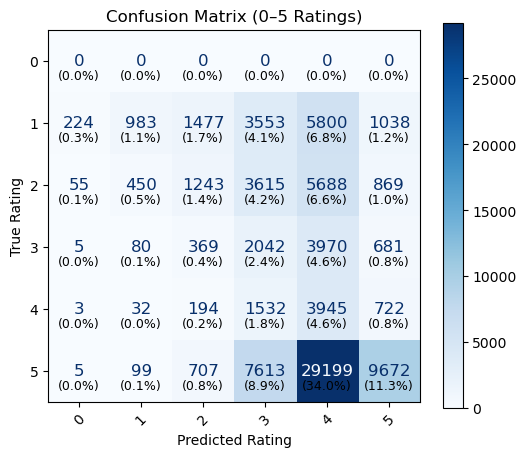

(449844, 3)
(449844, 3)

=== Testing params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 2, 'n_iter': 1} ===
  Left-out user 052f9630e3db689123da58fc108031d9: NDCG@10=0.0000, n_test_items=252
  Left-out user 05ab0303fcacd5a317b2ae09139d2f90: NDCG@10=0.2190, n_test_items=2550
  Left-out user 05e5cb7c62f3231151833fc2f9c14e26: NDCG@10=0.0000, n_test_items=168
  Left-out user 076f72958232d0807c41c7e9f998f700: NDCG@10=0.0000, n_test_items=2276
  Left-out user 087b10f90b88c964f3753b2e96d692af: NDCG@10=0.0000, n_test_items=32
  Left-out user 0b21e0687828ef44ea07681a70516403: NDCG@10=0.2000, n_test_items=1729
  Left-out user 0d3e5f43ebd0e0e1e7b6cd0dea2c834a: NDCG@10=0.0000, n_test_items=38
  Left-out user 0d9cb0e2fc8cdcc2c14f9280e68d7675: NDCG@10=0.0000, n_test_items=171
  Left-out user 0dbe1e9bc9b5fa04df02d7d41387200f: NDCG@10=0.0000, n_test_items=39
  Left-out user 0e69a81894779495dc08cecca018fb58: NDCG@10=0.0000, n_test_items=701
  Left-out user 0e95162c2b3c148

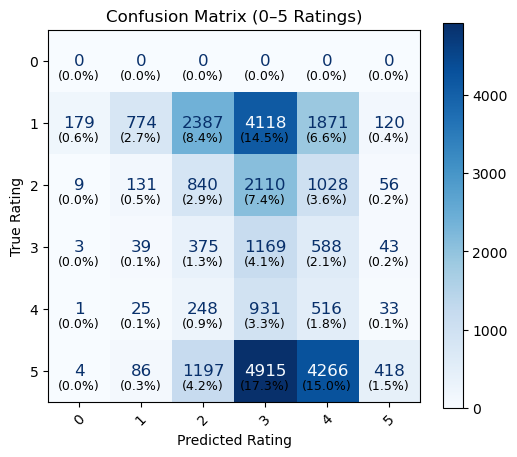

(148407, 3)
(148407, 3)

=== Testing params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 2, 'n_iter': 1} ===
  Left-out user 052f9630e3db689123da58fc108031d9: NDCG@10=0.0000, n_test_items=71
  Left-out user 05ab0303fcacd5a317b2ae09139d2f90: NDCG@10=0.2554, n_test_items=1097
  Left-out user 05e5cb7c62f3231151833fc2f9c14e26: NDCG@10=0.0000, n_test_items=83
  Left-out user 076f72958232d0807c41c7e9f998f700: NDCG@10=0.0851, n_test_items=767
  Left-out user 087b10f90b88c964f3753b2e96d692af: NDCG@10=0.0000, n_test_items=3
  Left-out user 0b21e0687828ef44ea07681a70516403: NDCG@10=0.2895, n_test_items=671
  Left-out user 0d3e5f43ebd0e0e1e7b6cd0dea2c834a: NDCG@10=0.0000, n_test_items=19
  Left-out user 0d9cb0e2fc8cdcc2c14f9280e68d7675: NDCG@10=0.0000, n_test_items=27
  Left-out user 0dbe1e9bc9b5fa04df02d7d41387200f: NDCG@10=0.0000, n_test_items=17
  Left-out user 0e69a81894779495dc08cecca018fb58: NDCG@10=0.0000, n_test_items=187
  Left-out user 0e95162c2b3c14828987a

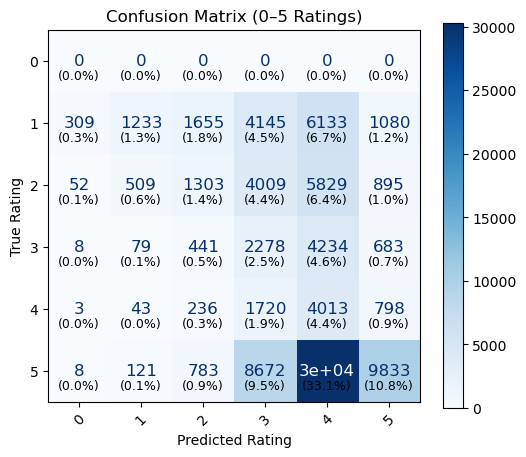

(478608, 3)
(478608, 3)

=== Testing params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 2, 'n_iter': 1} ===
  Left-out user 052f9630e3db689123da58fc108031d9: NDCG@10=0.0000, n_test_items=272
  Left-out user 05ab0303fcacd5a317b2ae09139d2f90: NDCG@10=0.2091, n_test_items=2765
  Left-out user 05e5cb7c62f3231151833fc2f9c14e26: NDCG@10=0.0000, n_test_items=176
  Left-out user 076f72958232d0807c41c7e9f998f700: NDCG@10=0.0000, n_test_items=2457
  Left-out user 087b10f90b88c964f3753b2e96d692af: NDCG@10=0.0000, n_test_items=32
  Left-out user 0b21e0687828ef44ea07681a70516403: NDCG@10=0.2381, n_test_items=1921
  Left-out user 0d3e5f43ebd0e0e1e7b6cd0dea2c834a: NDCG@10=0.0000, n_test_items=45
  Left-out user 0d9cb0e2fc8cdcc2c14f9280e68d7675: NDCG@10=0.0000, n_test_items=177
  Left-out user 0dbe1e9bc9b5fa04df02d7d41387200f: NDCG@10=0.0000, n_test_items=40
  Left-out user 0e69a81894779495dc08cecca018fb58: NDCG@10=0.0000, n_test_items=739
  Left-out user 0e95162c2b3c148

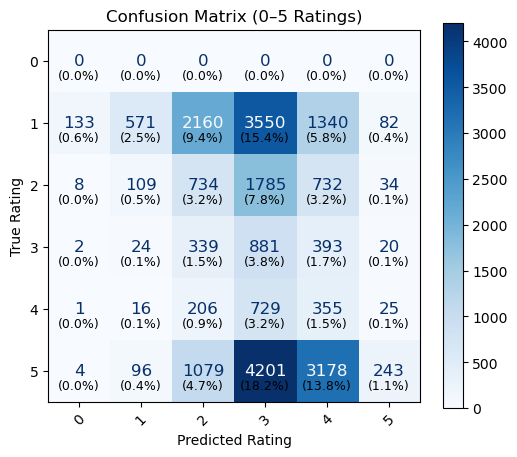

(119643, 3)
(119642, 3)

=== Testing params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 2, 'n_iter': 1} ===
  Left-out user 052f9630e3db689123da58fc108031d9: NDCG@10=0.0000, n_test_items=51
  Left-out user 05ab0303fcacd5a317b2ae09139d2f90: NDCG@10=0.3264, n_test_items=882
  Left-out user 05e5cb7c62f3231151833fc2f9c14e26: NDCG@10=0.0000, n_test_items=75
  Left-out user 076f72958232d0807c41c7e9f998f700: NDCG@10=0.0000, n_test_items=586
  Left-out user 087b10f90b88c964f3753b2e96d692af: NDCG@10=0.0000, n_test_items=3
  Left-out user 0b21e0687828ef44ea07681a70516403: NDCG@10=0.0851, n_test_items=479
  Left-out user 0d3e5f43ebd0e0e1e7b6cd0dea2c834a: NDCG@10=0.0000, n_test_items=12
  Left-out user 0d9cb0e2fc8cdcc2c14f9280e68d7675: NDCG@10=0.0000, n_test_items=21
  Left-out user 0dbe1e9bc9b5fa04df02d7d41387200f: NDCG@10=0.0000, n_test_items=16
  Left-out user 0e69a81894779495dc08cecca018fb58: NDCG@10=0.0000, n_test_items=149
  Left-out user 0e95162c2b3c14828987a4

In [50]:
#✅ Best params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 2, 'n_iter': 1}
#✅ Best RMSE on TEST: 1.5466, NDCG@3: 0.8031, normalized RMSE: 1.5466

param_grid = {
    'n_components': [2, 5, 10, 20, 50, 100, 124],
    'max_iter': [1000, 2000, 3000],
    'init': ['random'],
    'model_type': ['svd'],
    'n_iter': [1, 3, 5, 10, 15]
}

results_real = []

R_test, R_estimated, ndcg, k_ndcg, rmse, rmse_normalized, best_param = grid_search_mf_bias(df_mf_tiktok_real, param_grid, print_info=False)
print("All videos")
cm, acc, pre, rec, f1s = plot_confusion_matrix_ratings(R_test, R_estimated)
best_metrics = grid_search_mf_bias_loou_ndcg(df_mf_tiktok_real, best_param)

d = {"Data": "TikTok Real-World",
    "Quantile": 1.0, 
    "Duration": np.nan, 
    "Type": "all", 
    "Accuracy": accuracy_exp, 
    "Precision": precision_exp, 
    "Recall": recall_exp, 
    "F1 score": f1_exp,
    "ndcg": ndcg,
    "k_ndcg": k_ndcg,
    "rmse": rmse,
    "rmse_norm": rmse_normalized
}
d.update(best_metrics)
results_real.append(d)

d = {"Data": "TikTok Real-World", 
    "Accuracy": acc, 
    "Precision": pre, 
    "Recall": rec, 
    "F1 score": f1s,
    "ndcg": ndcg,
    "k_ndcg": k_ndcg,
    "rmse": rmse,
    "rmse_norm": rmse_normalized,
    "density": calculate_density(df_mf_tiktok_real)
    }
d.update(best_metrics)
results_combine.append(d)

for q in [0.2, 0.25, 0.5, 0.75, 0.8]:
    t = int(df_tiktok_real[["video_duration"]].quantile(q).iloc[0])
    print(f"Time split: {t}")
    video_ids_up_ts, video_ids_more_ts = select_short_videos(df_tiktok_real, time=t, col="video_duration")

    data_up_ts = df_mf_tiktok_real[df_mf_tiktok_real["video_id"].isin(video_ids_up_ts)]
    R_test, R_estimated, ndcg, k_ndcg, rmse, rmse_normalized, best_param = grid_search_mf_bias(data_up_ts, param_grid, print_info=False)
    print("Short videos")
    cm, acc, pre, rec, f1s = plot_confusion_matrix_ratings(R_test, R_estimated)
    best_metrics = grid_search_mf_bias_loou_ndcg(data_up_ts, best_param)
    d = {"Data": "TikTok Real-World", "Quantile": q, "Duration": t, "Type": "short", 
        "Accuracy": acc, 
        "Precision": pre, 
        "Recall": rec, 
        "F1 score": f1s,
        "ndcg": ndcg,
        "k_ndcg": k_ndcg,
        "rmse": rmse,
        "rmse_norm": rmse_normalized
        }
    d.update(best_metrics)
    results_real.append(d)
    
    
    
    data_more_ts = df_mf_tiktok_real[df_mf_tiktok_real["video_id"].isin(video_ids_more_ts)]
    R_test, R_estimated, ndcg, k_ndcg, rmse, rmse_normalized, best_param = grid_search_mf_bias(data_more_ts, param_grid, print_info=False)
    print("Long videos")
    cm, acc, pre, rec, f1s = plot_confusion_matrix_ratings(R_test, R_estimated)
    best_metrics = grid_search_mf_bias_loou_ndcg(data_more_ts, best_param)
    d = {"Data": "TikTok Real-World", "Quantile": q, "Duration": t, "Type": "long", 
        "Accuracy": acc, 
        "Precision": pre, 
        "Recall": rec, 
        "F1 score": f1s,
        "ndcg": ndcg,
        "k_ndcg": k_ndcg,
        "rmse": rmse,
        "rmse_norm": rmse_normalized
        }
    d.update(best_metrics)
    results_real.append(d)

In [51]:
df_results_real = pd.DataFrame(results_real)

In [52]:
df_results_real

,Data,Quantile,Duration,Type,Accuracy,Precision,Recall,F1 score,ndcg,k_ndcg,rmse,rmse_norm,avg_ndcg_loo,k_ndcg_loo,rmse_loo,rmse_normalized_loo,num_users_loo
0,TikTok Real-World,1.00,NaN,all,0.373092,0.347676,0.301097,0.287353,0.803080,3,1.546608,0.934442,0.055099,10,1.548382,0.950453,334
1,TikTok Real-World,0.20,11.0,short,0.267003,0.300913,0.201256,0.146581,0.832809,3,1.406352,0.966811,0.055528,10,1.401853,0.991252,333
2,TikTok Real-World,0.20,11.0,long,0.166622,0.292307,0.208601,0.137703,0.775050,3,1.586345,0.944788,0.051383,10,1.589052,0.956743,334
3,TikTok Real-World,0.25,12.0,short,0.264250,0.291024,0.208752,0.146834,0.837152,3,1.416223,0.969889,0.055733,10,1.408694,0.990514,333
4,TikTok Real-World,0.25,12.0,long,0.161621,0.294143,0.205649,0.135123,0.761250,3,1.590302,0.942622,0.053829,10,1.595609,0.957485,334
5,TikTok Real-World,0.50,17.0,short,0.235862,0.312268,0.216285,0.161006,0.827596,3,1.441783,0.948169,0.056083,10,1.437371,0.970440,334
6,TikTok Real-World,0.50,17.0,long,0.140232,0.284868,0.198070,0.119661,0.740472,3,1.639664,0.949582,0.051045,10,1.658574,0.967649,334
7,TikTok Real-World,0.75,33.0,short,0.208292,0.307819,0.213900,0.152377,0.818924,3,1.490892,0.945087,0.055470,10,1.490662,0.964555,334
8,TikTok Real-World,0.75,33.0,long,0.130513,0.279107,0.190505,0.109350,0.702213,3,1.696518,0.969212,0.044545,10,1.711314,0.979499,334
9,TikTok Real-World,0.80,41.0,short,0.204202,0.307485,0.211669,0.152363,0.808195,3,1.498499,0.942723,0.055125,10,1.501346,0.962807,334


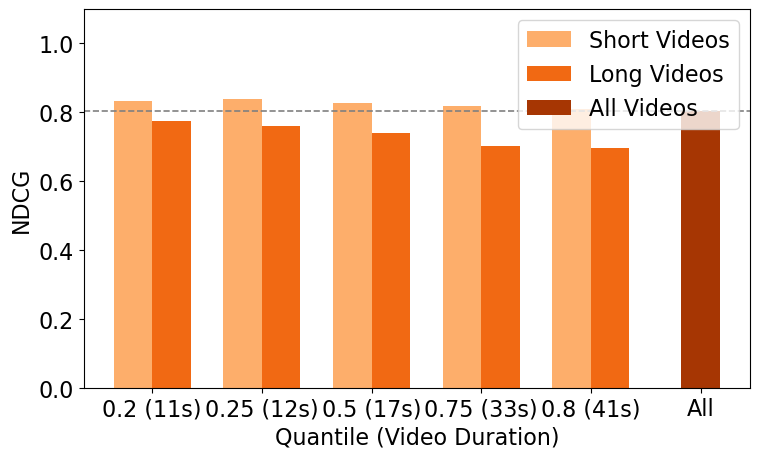

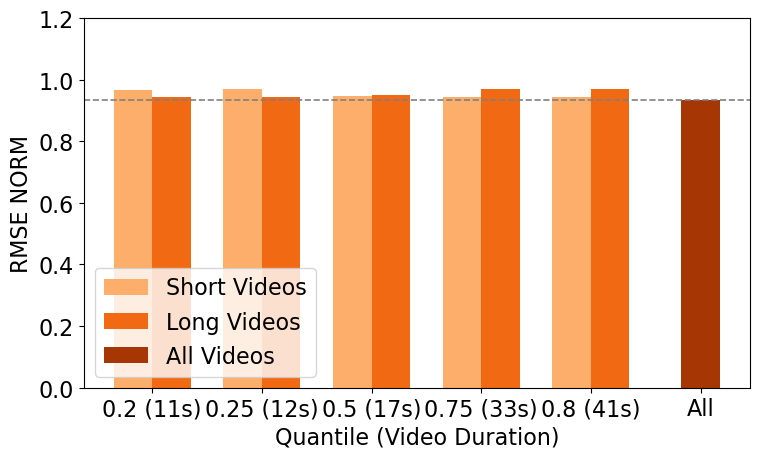

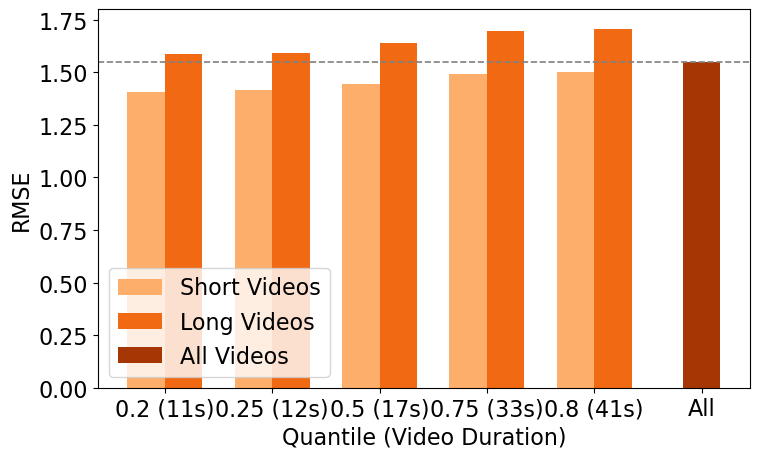

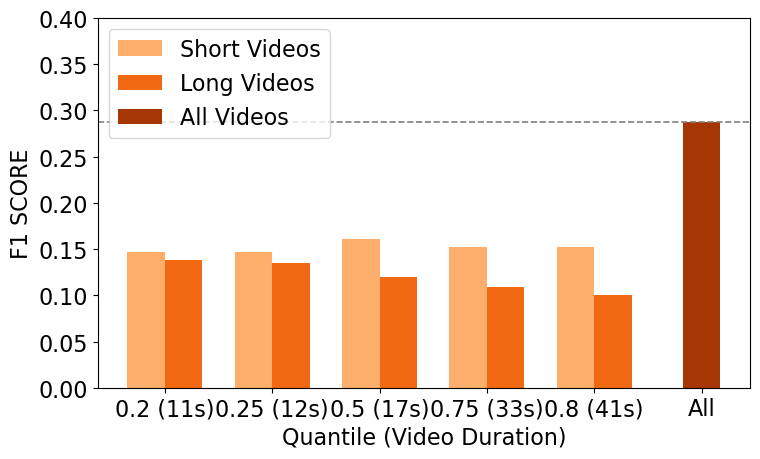

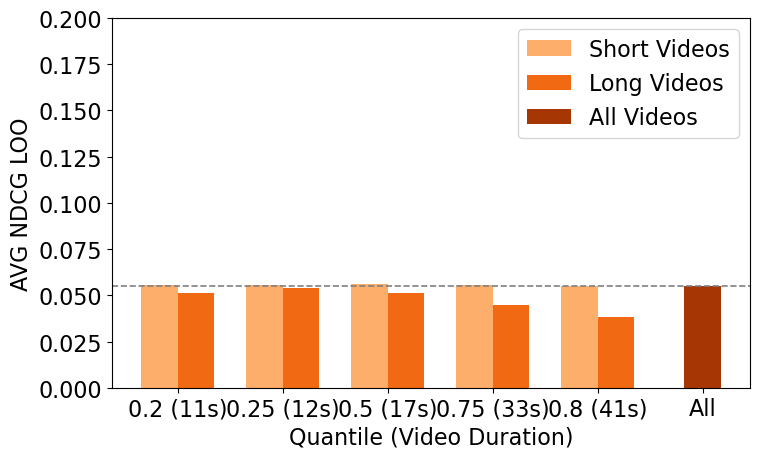

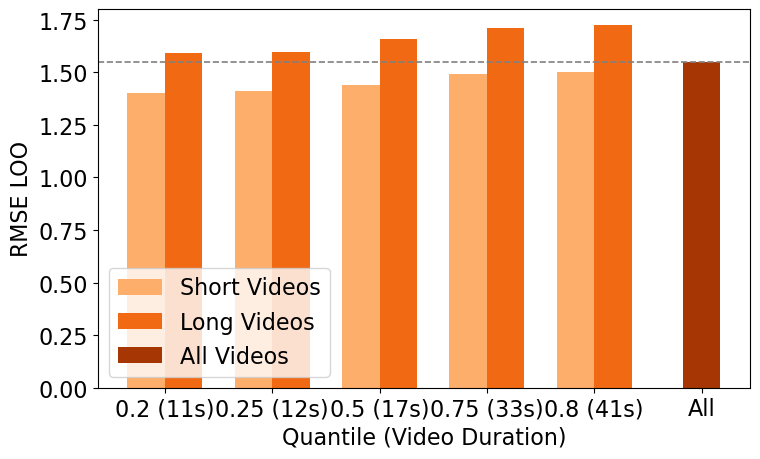

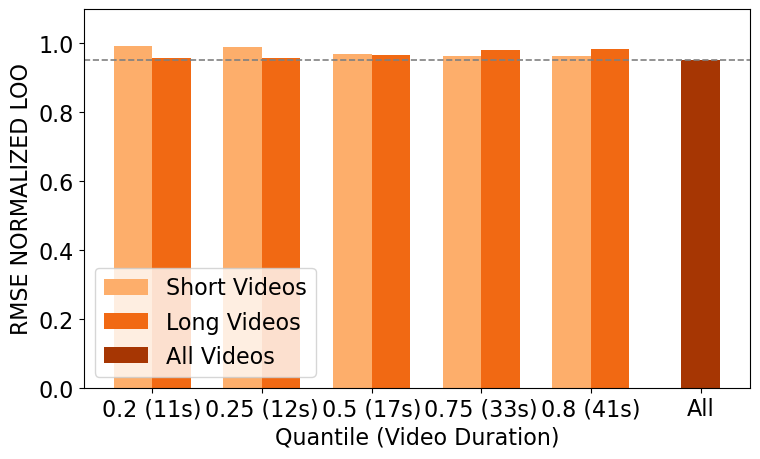

In [53]:
set_dim_fig(sizes=(16,20,20))
plot_mf_summary(df_results_real, note="tiktok-real")
set_dim_fig()

In [54]:
df_results_real.to_csv("data/results_mf_real.csv")

## MovieLens data

In [55]:
df_mf_ml = pd.read_csv('data/movielens-100k/u.data', sep='\t', names=['user_id', 'item_id', 'rating', 'timestamp'])
df_mf_ml.drop(columns=['timestamp'], inplace=True)
df_mf_ml.rename(columns={"item_id": "video_id"}, inplace=True)
df_mf_ml.head(5)

,user_id,video_id,rating
0,196,242,3
1,186,302,3
2,22,377,1
3,244,51,2
4,166,346,1


Text(0.5, 1.0, 'Distribution of video percentage watched "rating"')

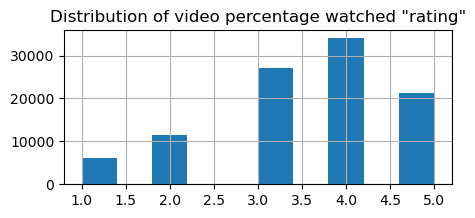

In [56]:
df_mf_ml[["rating"]].hist(figsize=(5,2))
plt.title("Distribution of video percentage watched \"rating\"")

In [57]:
_ = calculate_density(df_mf_ml)

Users: 943, Videos: 1682
Observed interactions: 100000
Density: 0.0630
Sparsity: 0.9370


Most active user: 405 (737 ratings)
Most rated video: 50 (583 ratings)


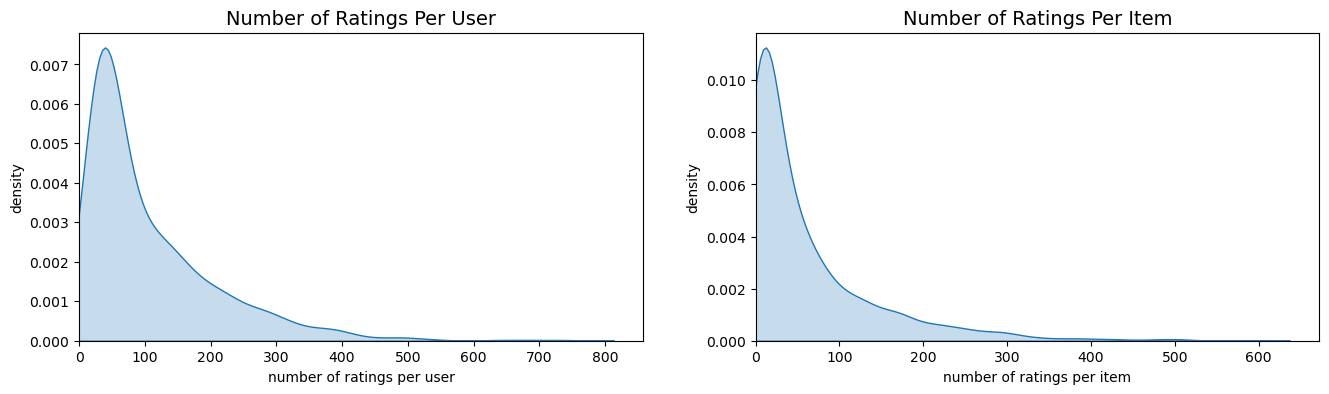

In [58]:
summary_plot_ratings(df_mf_ml)

In [59]:
param_grid = {
    'n_components': [2, 5, 10, 20, 50, 100, 124],
    'max_iter': [1000, 2000, 3000],
    'init': ['random'],
    'model_type': ['svd'],
    'n_iter': [1, 3, 5, 10, 15]
}

R_test, R_estimated, ndcg, k_ndcg, rmse, rmse_normalized, best_param = grid_search_mf_bias(df_mf_ml, param_grid)

(99859, 3) (79499, 3) (20360, 3)
cold items [1365 1371 1398]
79502 20357 19971.800000000003
Testing parameters: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 2, 'n_iter': 1}
svd 2 1000 random 1
Explained variance: 0.03725716727248565
Number of users used for NDCG: 943
RMSE: 0.9502, Normalized: 0.8454, NDCG@3: 0.8684
Testing parameters: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 2, 'n_iter': 3}
svd 2 1000 random 3
Explained variance: 0.04093235268294894
Number of users used for NDCG: 943
RMSE: 0.9477, Normalized: 0.8432, NDCG@3: 0.8697
Testing parameters: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 2, 'n_iter': 5}
svd 2 1000 random 5
Explained variance: 0.04097635057109182
Number of users used for NDCG: 943
RMSE: 0.9476, Normalized: 0.8432, NDCG@3: 0.8697
Testing parameters: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 2, 'n_iter': 10}
svd 2 1000 random 10
Explained vari

Test size: 20357
Accuracy: 0.4224
Precision (macro): 0.3855
Recall (macro): 0.2713
F1 Score (macro): 0.2783


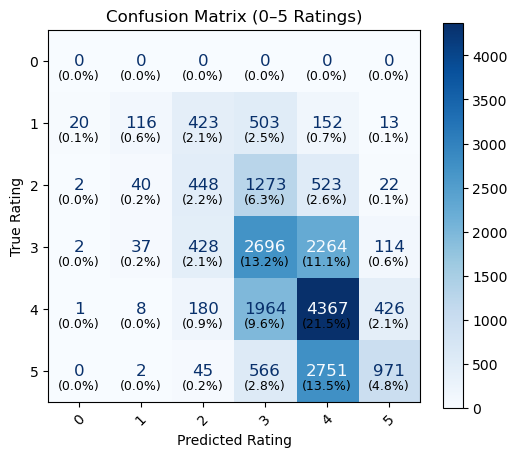

In [60]:
cm, acc, pre, rec, f1s = plot_confusion_matrix_ratings(R_test, R_estimated)

In [61]:
best_metrics = grid_search_mf_bias_loou_ndcg(df_mf_ml, best_param)

(100000, 3)
(100000, 3)

=== Testing params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 10, 'n_iter': 15} ===
  Left-out user 1: NDCG@10=0.0000, n_test_items=272
  Left-out user 2: NDCG@10=0.0000, n_test_items=62
  Left-out user 3: NDCG@10=0.0000, n_test_items=54
  Left-out user 4: NDCG@10=0.0000, n_test_items=24
  Left-out user 5: NDCG@10=0.0000, n_test_items=175
  Left-out user 6: NDCG@10=0.0000, n_test_items=211
  Left-out user 7: NDCG@10=0.0000, n_test_items=403
  Left-out user 8: NDCG@10=0.0000, n_test_items=59
  Left-out user 9: NDCG@10=0.0000, n_test_items=22
  Left-out user 10: NDCG@10=0.0000, n_test_items=184
  Left-out user 11: NDCG@10=0.0000, n_test_items=181
  Left-out user 12: NDCG@10=0.0000, n_test_items=51
  Left-out user 13: NDCG@10=0.0000, n_test_items=636
  Left-out user 14: NDCG@10=0.0000, n_test_items=98
  Left-out user 15: NDCG@10=0.0000, n_test_items=104
  Left-out user 16: NDCG@10=0.0000, n_test_items=140
  Left-out user 17: NDCG@10

In [62]:
d = {"Data": "MovieLens 100k", 
    "Accuracy": acc, 
    "Precision": pre, 
    "Recall": rec, 
    "F1 score": f1s,
    "ndcg": ndcg,
    "k_ndcg": k_ndcg,
    "rmse": rmse,
    "rmse_norm": rmse_normalized,
    "density": calculate_density(df_mf_ml)
    }
d.update(best_metrics)
results_combine.append(d)

Users: 943, Videos: 1682
Observed interactions: 100000
Density: 0.0630
Sparsity: 0.9370


In [63]:
df_results_combine = pd.DataFrame(results_combine) 
df_results_combine

,Data,Accuracy,Precision,Recall,F1 score,ndcg,k_ndcg,rmse,rmse_norm,density,avg_ndcg_loo,k_ndcg_loo,rmse_loo,rmse_normalized_loo,num_users_loo
0,TikTok Experiment,0.373092,0.347676,0.301097,0.287353,0.887181,3,1.332465,0.809023,0.611310,0.807134,10,1.320171,0.787932,80
1,TikTok Real-World,0.185445,0.305384,0.211289,0.144749,0.803080,3,1.546608,0.934442,0.083637,0.055099,10,1.548382,0.950453,334
2,MovieLens 100k,0.422361,0.385454,0.271317,0.278305,0.873018,3,0.938817,0.835307,0.063047,0.001725,10,1.022048,0.907948,943


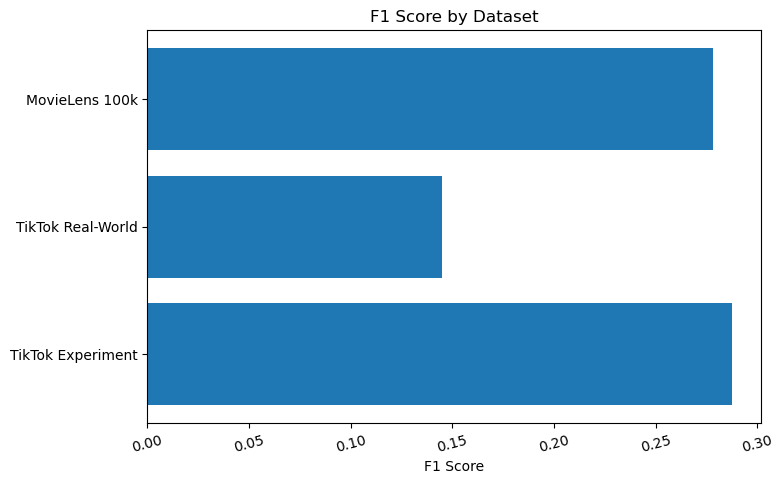

In [64]:
# Create bar plot
plt.figure(figsize=(8, 5))
plt.barh(df_results_combine["Data"], df_results_combine["F1 score"])
plt.xlabel("F1 Score")
plt.title("F1 Score by Dataset")
plt.xticks(rotation=15)
plt.tight_layout()

# Show plot
plt.show()

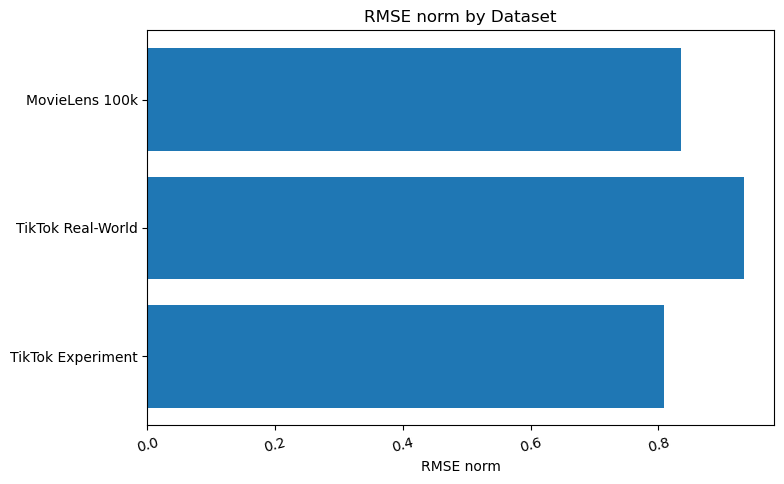

In [65]:
# Create bar plot
plt.figure(figsize=(8, 5))
plt.barh(df_results_combine["Data"], df_results_combine["rmse_norm"])
plt.xlabel("RMSE norm")
plt.title("RMSE norm by Dataset")
plt.xticks(rotation=15)
plt.tight_layout()

# Show plot
plt.show()

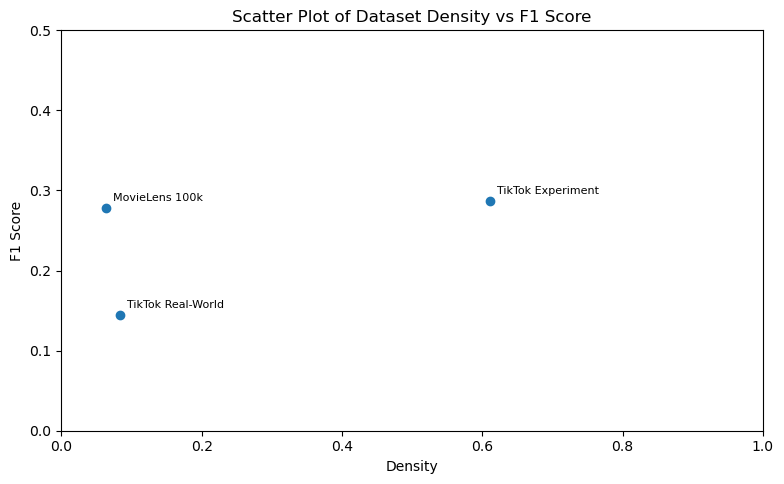

In [66]:
# Example column to annotate with – replace "model" with your desired column name
annotation_column = "Data"  # change this to your actual column name in df_results_combine

plt.figure(figsize=(8, 5))
plt.scatter(df_results_combine["density"], df_results_combine["F1 score"])

# Add annotations
for i, txt in enumerate(df_results_combine[annotation_column]):
    plt.annotate(txt,
                 (df_results_combine["density"].iloc[i], df_results_combine["F1 score"].iloc[i]),
                 textcoords="offset points",  # how to position the text
                 xytext=(5, 5),              # distance from the data point
                 fontsize=8)

plt.xlabel("Density")
plt.xlim(0,1)
plt.ylabel("F1 Score")
plt.ylim(0,0.5)
plt.title("Scatter Plot of Dataset Density vs F1 Score")
plt.tight_layout()
plt.show()

In [67]:
df_results_combine.to_csv("data/results_mf_combined.csv")

# Reduzing the size of ML data for comparison with TikTok Experiment data

In [68]:
def density(m):
    total_possible = m.shape[0] * m.shape[1]
    non_zero = (m != 0).sum().sum()
    return non_zero / total_possible
        
def extract_dense_subset_random(matrix, target_density=0.6, n_users_sample=1000, min_users=80, min_videos=100, random_state=42):
    
    np.random.seed(random_state)

    # Step 1: Randomly sample users
    sampled_users = np.random.choice(matrix.index, size=min(n_users_sample, matrix.shape[0]), replace=False)
    dense_matrix = matrix.loc[sampled_users]

    current_density = density(dense_matrix)
    changed = True

    while current_density < target_density and changed:
        changed = False
        # Shuffle users and videos before filtering (tie-breaking)
        dense_matrix = dense_matrix.sample(frac=1, random_state=random_state)
        dense_matrix = dense_matrix.sample(frac=1, axis=1, random_state=random_state)

        # Filter users with <= median interactions
        user_activity = (dense_matrix != 0).sum(axis=1)
        median_activity = user_activity.quantile(0.5)
        active_users = user_activity[user_activity > median_activity].index
        dense_matrix = dense_matrix.loc[active_users]

        # Filter videos with <= median interactions
        video_popularity = (dense_matrix != 0).sum(axis=0)
        median_popularity = video_popularity.quantile(0.5)
        popular_videos = video_popularity[video_popularity > median_popularity].index
        dense_matrix = dense_matrix[popular_videos]

        # Recompute density
        new_density = density(dense_matrix)
        if new_density > current_density:
            current_density = new_density
            changed = True

        # Check if the number of remaining users or videos falls below a minimum threshold
        if dense_matrix.shape[0] < min_users or dense_matrix.shape[1] < min_videos:
            break

    return dense_matrix

In [69]:
user_video_matrix = df_mf_ml.pivot_table(index='user_id', columns='video_id', values='rating', aggfunc='mean', fill_value=0)

dense_matrices = []
for i in range(5):
    dense_subset = extract_dense_subset_random(
        user_video_matrix,
        target_density=0.6,
        n_users_sample=650,  # larger than final dense block
        min_users=80,
        min_videos=100,
        random_state=42 + i
    )
    dense_matrices.append(dense_subset)
    print(f"Submatrix {i+1}: users={dense_subset.shape[0]}, videos={dense_subset.shape[1]}, density={(dense_subset!=0).sum().sum()/(dense_subset.shape[0]*dense_subset.shape[1]):.4f}")

Submatrix 1: users=80, videos=200, density=0.6663
Submatrix 2: users=80, videos=195, density=0.6780
Submatrix 3: users=80, videos=197, density=0.6754
Submatrix 4: users=80, videos=202, density=0.6601
Submatrix 5: users=79, videos=206, density=0.6722


In [70]:
dense_dfs = []  # to store the long-format versions

for i, dense_subset in enumerate(dense_matrices, start=1):
    # Convert the matrix back into long format
    dense_long = (
        dense_subset
        .stack()  # converts from wide to long
        .reset_index()
        .rename(columns={0: 'rating'})
    )
    
    # Keep only non-zero ratings (i.e., actual interactions)
    dense_long = dense_long[dense_long['rating'] != 0]
    
    # Optionally, add a sample ID column
    dense_long['sample_id'] = i
    
    dense_dfs.append(dense_long)
    
    print(f"Sample {i}: {len(dense_long)} interactions, users={dense_subset.shape[0]}, videos={dense_subset.shape[1]}")

# Combine all samples into one DataFrame (optional)
all_dense_samples = pd.concat(dense_dfs, ignore_index=True)

Sample 1: 10661 interactions, users=80, videos=200
Sample 2: 10577 interactions, users=80, videos=195
Sample 3: 10645 interactions, users=80, videos=197
Sample 4: 10667 interactions, users=80, videos=202
Sample 5: 10939 interactions, users=79, videos=206


In [71]:
# Prepare lists of user and video sets
user_sets = [set(df['user_id']) for df in dense_dfs]
video_sets = [set(df['video_id']) for df in dense_dfs]

user_overlap_results = []
video_overlap_results = []

# Pairwise combinations of samples
for (i, j) in itertools.combinations(range(len(dense_dfs)), 2):
    u_overlap = len(user_sets[i].intersection(user_sets[j]))
    v_overlap = len(video_sets[i].intersection(video_sets[j]))
    
    user_overlap_results.append({
        'sample_i': i+1,
        'sample_j': j+1,
        'shared_users': u_overlap,
        'prop_users_i': u_overlap / len(user_sets[i]),
        'prop_users_j': u_overlap / len(user_sets[j]),
    })
    
    video_overlap_results.append({
        'sample_i': i+1,
        'sample_j': j+1,
        'shared_videos': v_overlap,
        'prop_videos_i': v_overlap / len(video_sets[i]),
        'prop_videos_j': v_overlap / len(video_sets[j]),
    })

# Convert to DataFrames for easy viewing
user_overlap_df = pd.DataFrame(user_overlap_results)
video_overlap_df = pd.DataFrame(video_overlap_results)

print("=== User Overlap ===")
print(user_overlap_df.round(3))

print("\n=== Video Overlap ===")
print(video_overlap_df.round(3))

=== User Overlap ===
   sample_i  sample_j  shared_users  prop_users_i  prop_users_j
0         1         2            52         0.650         0.650
1         1         3            48         0.600         0.600
2         1         4            50         0.625         0.625
3         1         5            53         0.662         0.671
4         2         3            58         0.725         0.725
5         2         4            50         0.625         0.625
6         2         5            56         0.700         0.709
7         3         4            53         0.662         0.662
8         3         5            58         0.725         0.734
9         4         5            52         0.650         0.658

=== Video Overlap ===
   sample_i  sample_j  shared_videos  prop_videos_i  prop_videos_j
0         1         2            180          0.900          0.923
1         1         3            184          0.920          0.934
2         1         4            181          0.905

## MF TikTok Experiment data & MF ML 5 toy datasets

In [72]:
param_grid = {
    'n_components': [2, 5, 10, 20, 50, 100, 124],
    'max_iter': [1000, 2000, 3000],
    'init': ['random'],
    'model_type': ['svd'],
    'n_iter': [1, 3, 5, 10, 15]
}

results_ml = []

for i, df_ml_subset in enumerate(dense_dfs):
    d = calculate_density(df_ml_subset)
    R_test, R_estimated, ndcg, k_ndcg, rmse, rmse_norm, best_model = grid_search_mf_bias(df_ml_subset, param_grid, print_info=False)
    results_ml.append({"ML toy": i, "density": d, "ndcg": ndcg, "k_ndcg": k_ndcg, "rmse": rmse, "rmse_norm": rmse_norm})

Users: 80, Videos: 200
Observed interactions: 10661
Density: 0.6663
Sparsity: 0.3337
(10661, 4) (8500, 4) (2161, 4)
8500 2161 2132.2000000000003

✅ Best params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 2, 'n_iter': 15}
✅ Best RMSE on TEST: 0.8743, NDCG@3: 0.8924 (len:80), normalized RMSE: 0.8743

📈 Explained Variance (for best SVD only): 0.12178879067688897

📈 Reconstruction Error (for best NMF only): None

📈 Reconstruction Error Normalized(for best NMF only): None
Users: 80, Videos: 195
Observed interactions: 10577
Density: 0.6780
Sparsity: 0.3220
(10577, 4) (8431, 4) (2146, 4)
8431 2146 2115.4

✅ Best params: {'init': 'random', 'max_iter': 1000, 'model_type': 'svd', 'n_components': 2, 'n_iter': 3}
✅ Best RMSE on TEST: 0.8696, NDCG@3: 0.8888 (len:80), normalized RMSE: 0.8696

📈 Explained Variance (for best SVD only): 0.12470632075417712

📈 Reconstruction Error (for best NMF only): None

📈 Reconstruction Error Normalized(for best NMF only): None
Users: 

In [73]:
results_ml_df = pd.DataFrame(results_ml)
results_ml_df

,ML toy,density,ndcg,k_ndcg,rmse,rmse_norm
0,0,0.666312,0.892361,3,0.874271,0.849928
1,1,0.678013,0.888840,3,0.869631,0.836298
2,2,0.675444,0.883374,3,0.862877,0.847761
3,3,0.660087,0.860602,3,0.906127,0.834280
4,4,0.672176,0.868050,3,0.917469,0.860553
